# Actual Causality Benchmark

> **Summary.** PCI versus Halpern–Pearl-style actual-cause probabilities on the generalised throwing problem. Includes exact actual-cause computations (one pair, two pairs, scaling sweep) and approximate estimation via `SearchForExplanation`. Generates the runtime, search-space, and accuracy plots reported in the paper's actual-causality benchmarking section.

In [1]:
import os
import pickle
import sys
from itertools import chain, combinations
from time import time

import matplotlib.pyplot as plt
import pandas as pd
import pyro
import pyro.distributions as dist
import seaborn as sns
import torch
from chirho.interventional.handlers import do
from chirho.observational.handlers import condition
from IPython.display import Image, display
from loguru import logger

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler
from pci.tools.find_root import find_repo_root

# Smoke-test mode is triggered by ``CI=1``. It runs the notebook end-to-end on
# a tiny problem budget so the full pipeline (exact + approximate benchmarks
# + plots) executes without kairos and without the cached results from a real
# run. The non-smoke settings reproduce the figures shown in the paper.
smoke_test = "CI" in os.environ

root = find_repo_root()
results_dir = os.path.join(root, "docs/source/ac_benchmark")
os.makedirs(results_dir, exist_ok=True)

print(f"Results will be saved to {results_dir}")

logger.remove()
logger.add(sys.stderr, level="INFO" if smoke_test else "DEBUG")


if smoke_test:
    # Sample sizes are deliberately offset from `num_worlds_at_site` so the
    # `broadcast_mask` heuristic in `condition_on_interventional_regime`
    # picks the sampling axis unambiguously.
    runtime_limit = 0.05  # 3 s per benchmark run
    num_worlds_at_site = 3
    initial_samples_small = 8
    initial_samples_large = 16
else:
    runtime_limit = 60  # minutes
    num_worlds_at_site = 10
    initial_samples_small = 250
    initial_samples_large = 500

runtime_limit_seconds = runtime_limit * 60

# change to True to force a fresh run; smoke tests always run fresh
fresh_run = True if smoke_test else False


Results will be saved to /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark


## Overview

### Motivations
A standard minimally interesting example used in the discussion of actual causality uses categorical variables: Sally and Billy pick up stones and throw them at a bottle. Sally’s stone gets there first, shattering the bottle. Both throws are perfectly accurate, so Billy’s stone would have shattered the bottle had it not been preempted by Sally’s throw. The intuition is that Sally's throw is responsible for the shattering, but not so Billy's. However, it is false that had Sally not thrown the stone, the bottle would not have shattered, so the simple counterfactual condition fails, which motivates the search for a better definition of responsibility attribution.

In this case study, we "mutliply" the structure underlying the classical bottle-throwing example with the goal to evaluate the extent to which the exact actual causality computation can handle it, and the extent and performance of the approximate estimation methods that use `SearchForExplanation`.

### Generalized throwing problem
For a problem size $n$, we define the corresponding deterministic model in which there will be $n$ "copies" of "Sally throwing" events $A_i$ and and $n$ copies of "Bill throwing" events, $B_i$, $i = 1, \dots n$. For each pair $A_i, B_i$ we mimick the overdetermination and undercutting in the same fashion they played out in the original example: $B_i$ succeeds only if $B_i$ throws and $A_i$ doesn't. The final outcome $C$ is triggered if at each $i$ we have a hit, i.e. either $A_i$ or $B_i$. This gives a scalable challenge akin to the original one. 

In other words, we consider binary variables   $A_1,\dots,A_n, B_1,\dots,B_n \in \{0,1\}$ 
where $A_i$ represents Sally’s $i$-th throw and $B_i$ represents Billy’s $i$-th throw.

For each pair $(A_i, B_i)$, we introduce endogenous variables $W^a_i, W^b_i \in \{0,1\}$ indicating whether $A_i$ ($B_i$) hit the target, ie. for each $i = 1,\dots,n$,
$$
W^a_i = A_i \,\,\,\,\, W^b_i = (B_i \land \lnot A_i).
$$

The final bottle-shattering outcome $C$ occurs iff every pair produces a hit:
$$
C = \bigwedge_{i=1}^n \left( W^a_i \vee W^b_i\right).
$$



The model also allows us to analytically compute responsibility indicators $R_i$ during a forward pass for evaluation purposes:

$$
R_i =
\begin{cases}
1, & \text{if } W^a_i = 1,\\[4pt]
2, & \text{if } W^b_i = 1,\\[4pt]
0, & \text{otherwise}.
\end{cases}
$$

### Explicit actual cause computations
First, we implement the original explicit actual causality calculation. Given a particular probelm size and a particular input values, the procedure attempts to decide which variables are responsible as follows:

1. consider all possible subsets of all cause candidates,
2. consider all possible witness sets (subsets of all witness candidates),
3. for each subset of the former looking for an existential necessity claim witness among the latter. 

We incorporate factivity, by only considering input settings that result in $C=1$, and minimality requirements, by dropping cause subsets which are not subset-minimal. Features deemed responsible are those and only those that end up in a minimal identified subset.

### Approximate estimation using `SearchForExplanation`

The approximate estimator below is the Monte Carlo specialisation of Definition 9 in the paper, used to produce the AC-benchmark figures. The body of the paper is separable from this particular inference choice; other estimators can be substituted at the user's discretion.

```
ALGORITHM 1: Approximate PCI estimator on the scaled throwing problem
─────────────────────────────────────────────────────────────────────────
Inputs:
  PSCM M for size-n throwing problem; factual world (s*, w*, c*)
  cardinality bounds  n_s, n_w
  total sample budget N
  witness flag  wit ∈ {on, off}            // wit=off ⟺ W := ∅
Output:
  per-site verdicts  v_i ∈ {A_i, B_i},  i = 1..n

1.  if wit = off:  W ← ∅                  // no witness candidates at all
2.  for each X ∈ S:  L[X] ← []            // per-suspect score lists
3.  for j = 1, …, N:
4.      draw u_j ~ P_U
5.      sample k_s ~ Unif{1,…,n_s},  k_w ~ Unif{0,…,n_w}
6.      sample C_j ⊆ S   uniformly with |C_j| = k_s
7.      sample D_j ⊆ W   uniformly with |D_j| = k_w        // witnesses dropped
8.      T_j ← W \ D_j                                       // active witnesses
9.      c'_j ← 1 − s*|_{C_j}             // ε-excised reduces to bit-flip on {0,1}
10.     // Same noise u_j shared by both worlds (counterfactual coupling)
11.     y^s_j ← M.run(u_j, do(C_j = s*|_{C_j}, T_j = w*|_{T_j}))   // sufficiency
12.     y^n_j ← M.run(u_j, do(C_j = c'_j,      T_j = w*|_{T_j}))   // necessity
13.     // Sufficiency world computed but not read out: AC has no sufficiency
14.     for each X ∈ C_j:
15.         L[X].append( |y^n_j − c*| )
16. for each X ∈ S:  score[X] ← nanmean(L[X])
17. for each site i = 1..n:  v_i ← argmax( score[A_i], score[B_i] )
18. return (v_1, …, v_n)
```

The algorithm draws $N$ intervention configurations under shared noise. The active suspect set $\mathbf{C}_j$ (line 6) is drawn at uniformly chosen cardinality $k_s \in \{1,\dots,n_s\}$; the dropped witness set $D_j$ (line 7) is drawn the same way at $k_w \in \{0,\dots,n_w\}$, and the active witnesses on line 8 are the complement $\mathbf{W}\setminus D_j$ — so $n_w$ bounds the number of witnesses *dropped*, not the number kept, and the active witness set has size $|\mathbf{W}|-n_w$ or larger. The witness ablation flag `wit = off` is handled once on line 1 by emptying $\mathbf{W}$; this collapses the witness machinery on lines 7–8 and 11–12 to no-ops, producing the dotted accuracy curves on the plot below.

Alternative values on line 9 are bit flips: on $\{0,1\}$ the $\epsilon$-excised alternative-value distribution has a single support point and $\epsilon$ plays no role; the explicit sampling form is preserved so that the same routine runs on continuous benchmarks. The two interventional worlds on lines 11–12 share the noise realisation $\mathbf{u}_j$ drawn on line 4 — the standard counterfactual coupling — which lets the per-suspect score on lines 14–16 be read off as the nan-mean of $|y^n_j - c^\star|$ over the draws in which $X\in\mathbf{C}_j$. The sufficiency outcome $y^s_j$ is computed but not consumed: the AC verdict against which we benchmark has no sufficiency clause, so we read only the necessity world. The joint estimator with sufficiency active is exercised in the synthetic benchmark notebook, where AC has no comparable verdict to benchmark against. At each site $i = 1..n$, line 17 returns the suspect — $A_i$ or $B_i$ — with the higher mean.

One additional knob is set inside the alternative-value sampler rather than at the algorithm level: the implementation runs with `conditioned_alternatives = True`, conditioning the alternative-value distribution on the witness interventions. On $\{0,1\}$ with a bit flip this has no effect; in continuous benchmarks it tightens the alternative distribution to remain compatible with the witness-pinning regime.


### Benchmarking setup
For each problem size we sample up to 10 "world" inputs (for low problem size, there are fewer unique ones), ensuring outcome factivity is satisfied. We also instantiate models of that size. At each "world" we use the two algorithms to estimate which features are responsible in those models under those inputs, and evaluate accuracy by comparing to the analytically available answer computed during the forward pass of the models. Once completed, we move to the next problem size. A problem size $m$ is determined by how many "copies" of variables we're dealing with at each $A/B$ site. This translates into the number of variables in the model ($R$ aside) by taking $4n+1$ (locations: $A, B, W^a, W^b$, each with $n$ sites, plus one outome variable). We use the approximate methods with a few different settings, which we will explain below for each method we stop the procedure after 60 minutes.

Settings of the approximate method:

1. First, we choose what initial sample size to use: these are the values sampled from the model, each run coming with a potentially different selection of active antecedents, fixed witnesses, and alternative values for the active antecedents. This sample size is used for problem size 1 with 5 variables.
2. Then, on purpose trying to deteriorate the approximate method performance, we increase the sample size linearly with the problem size. This means that for any problem size $n$, we use ($n \times $  factor $\times $  initial sample size) samples. Obviously, performance depends on both the intial sample size this factor, and to illustrate we also use a case with initial sample size 250 and 500 and factors 0.5 and 1.
3. Another question is whether the presence of witness interventions improves performance, so for ablationwe include two runs that do not use witnesses ($wit$ setting).
4. The default setting for the max number of intervened antecedents is 4, and so is the default setting for the max number of witness elements dropped. This speeds up computation and lowers the variance, but effectively works approximating the answer to a slightly different question, i.e. whether there are witness sets of size at least (number of witnesses - 4) which do the job. The algorith with this setting here won't perform too badly partially because of the problem structure (we will comment on this later when talking about limitations), but a conceptually more adequate method should put both constraints at $n+4$, effectively allowing subsets of variables of any size in the search. We include one run that does that for comparison (we call this setting "dynamic set sizes", hence "dyn" in the legend).





### Benchmarking results
We inspect three aspects: runtime per each "input world", the size of the search space used, and the accuracy rate. Let's start with runtime.

In [2]:
if not smoke_test:
    display(Image(filename="ac_benchmark/plot1_runtime.png"))


We see the exact computation times out at a relatively low problem size due to combinatorial explosion. For the approximate runs, speed seems mostly determined by sample size growth patterns.

Next, let's take a look at search spaced actually used. For the exact computation, these are powerset sizes, for the others these are unique samples. Due to large differences between the exact and the approximate method, the plot is on the log scale.

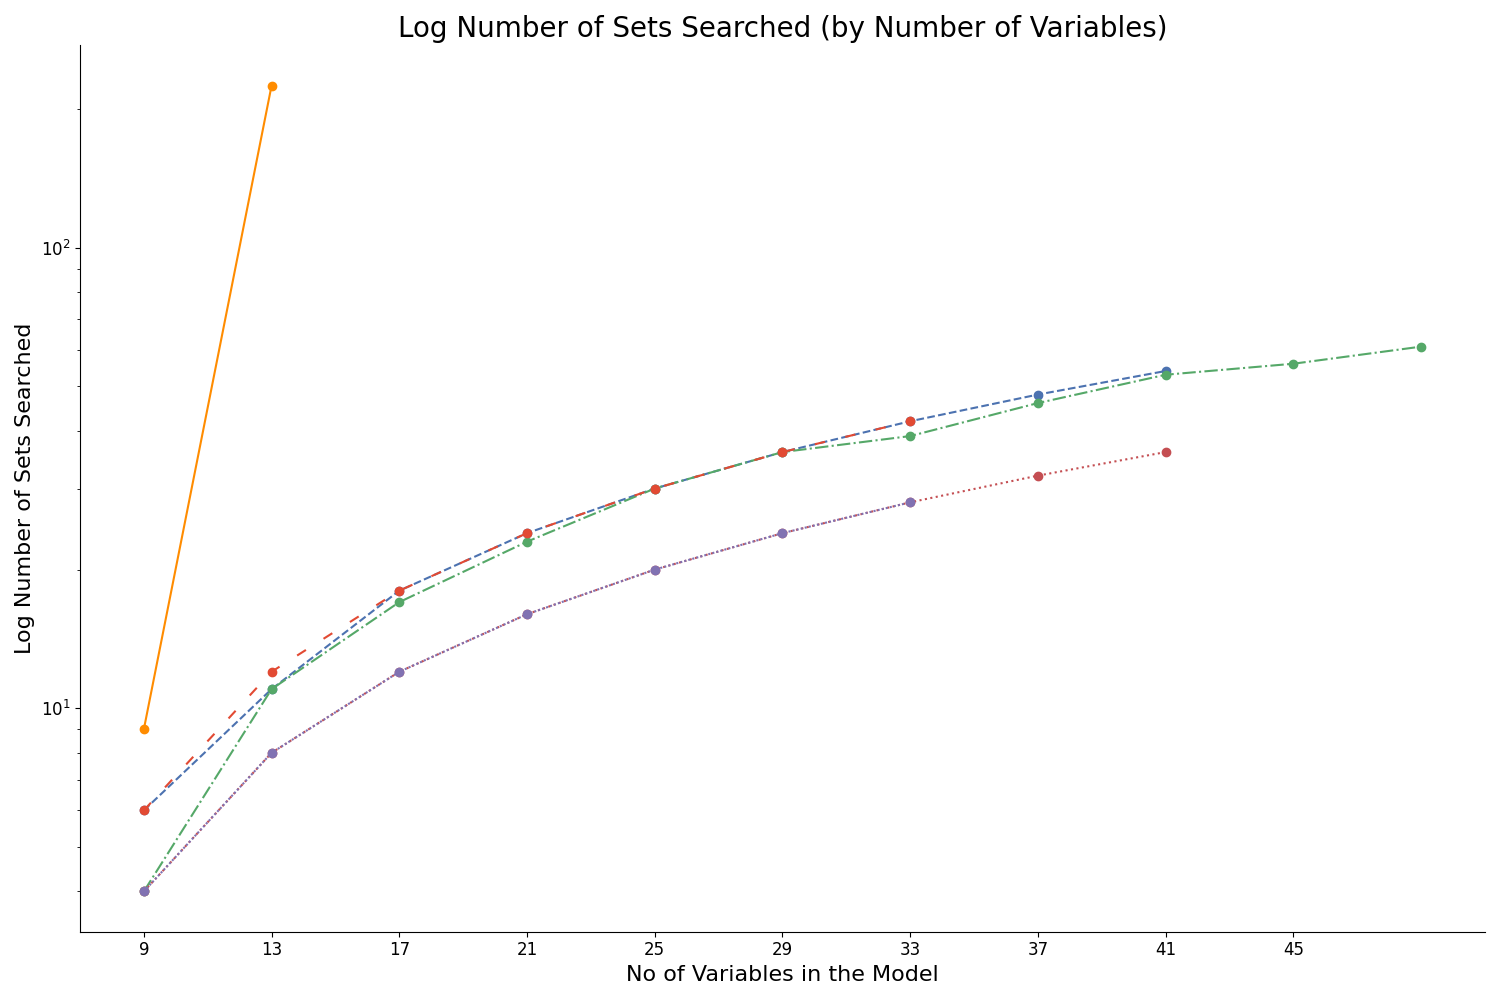

In [3]:
if not smoke_test:
    display(Image(filename="ac_benchmark/plot2_search_space.png"))


Finally, let's look at accuracy rates across different methods and problem sizes. The approximate methods' performance drops with problem size, the conjecture is that this is mostly because the linear sample size growth patterns used do not match the fast increase of the underlying powersets. Nevertheless, the structure of the problem allows for decent responsibility guesses based on relatively low sample sizes.

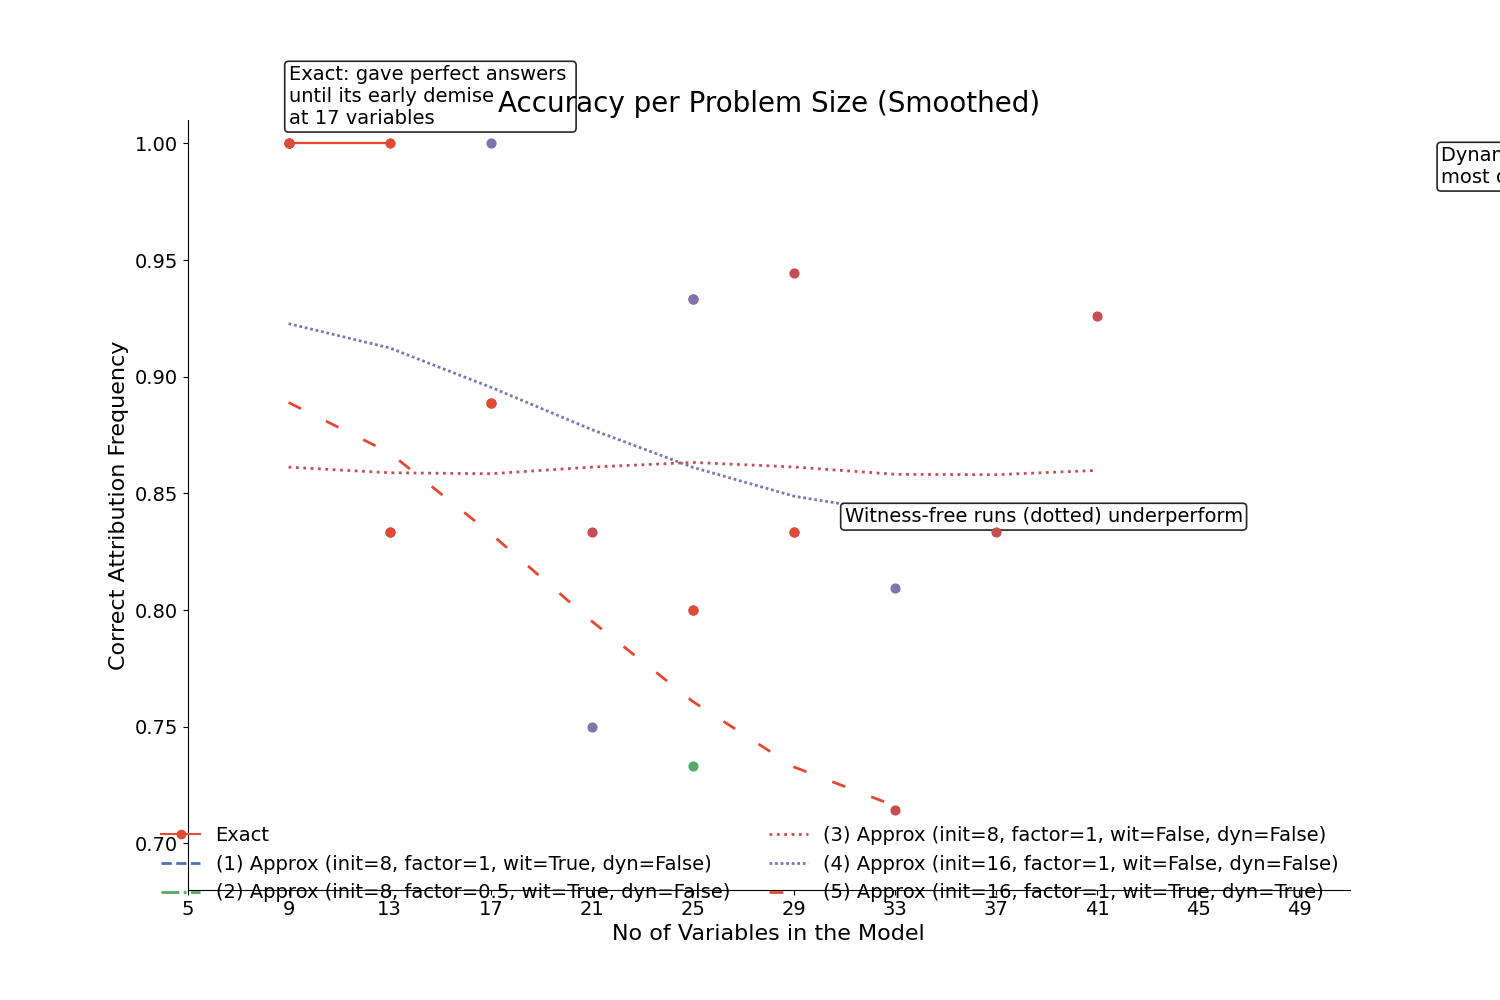

In [4]:
if not smoke_test:
    display(Image(filename="ac_benchmark/plot3_accuracy.png"))


### Limitations
While the stone-throwing example is typically used to illustrate how hard causal attribution is in the presence of overdetermination and undercutting, even when scaled, it is in some sense relatively easy, admitting constraints that can be exploited, even when scaled up to over a hundred variables. The key factors here are:

1. For each $i, j <n$, we know that the responsiblity of $A_i/B_i$ is independent of the responsibility of $A_j/B_j$. 
2. For each $i,j<n$, we know, given $C=1$ and the problem structure, that exactly one of $A_i, B_i$ is responsible.
3. Due to point 1 we know that if there is a witness set for the responsibility of $A_i/B_i$, any superset thereof will also be a witness set for the same attribution. That's the main reason why we could get away with low max-witness-dropout rate without loosing too much perfornace.
4. All the variables involved are categorical and binary. 


So, while the value of this benchmark is that it is a step in the direction of understaning the capabilities of the approximate method, and of how these surpass those of exact computations for this problem which already from some perspective is somewhat hard, the task of formulating more challenging and more realistic benchmarks and evaluating the performance of the approximate methods studied here remains an exciting path of improvement. 

## Code

### The scaled throwing model

In [5]:
def internal_model_factory(num_at_site: int = 1):
    def internal_model(**kwargs):
        As = {}
        Bs = {}
        Was = {}
        Wbs = {}
        Rs = {}

        for i in range(num_at_site):
            As[f"A{i}"] = kwargs.get(f"A{i}")
            Bs[f"B{i}"] = kwargs.get(f"B{i}")

            Wa_val = Was[f"Wa{i}"] = pyro.deterministic(f"Wa{i}", As[f"A{i}"])

            Wb_val = Bs[f"B{i}"] * (1 - Wa_val)

            Wb_val = pyro.deterministic(f"Wb{i}", Wb_val)

            Rs[f"R{i}"] = pyro.deterministic(f"R{i}", Wa_val + Wb_val * 2)

        rkeyes = list(Rs.keys())
        C = Rs[rkeyes[0]].clone() > 0
        for rk in rkeyes[1:]:
            C &= Rs[rk] > 0
        C = pyro.deterministic("C", C.int())

        return C

    return internal_model

In [6]:
# simple run for one site, replicating the classical example

simple_model = internal_model_factory(num_at_site=1)

A0 = torch.tensor([0, 0, 1, 1])
B0 = torch.tensor([0, 1, 0, 1])

with pyro.poutine.trace() as tr:
    out = simple_model(A0=A0, B0=B0)
print(out)

nodes = tr.trace.nodes
print(nodes.keys())

Wa0s = nodes["Wa0"]["value"]
assert torch.equal(Wa0s, (A0))
print(f"Wa0s: {Wa0s}")
Wb0s = nodes["Wb0"]["value"]
assert torch.equal(Wb0s, ((B0 == 1) & (A0 == 0)).to(A0.dtype))
print(f"Wb0s: {Wb0s}")
R0s = nodes["R0"]["value"]
assert torch.equal(R0s, Wa0s + Wb0s * 2)
print(f"R0s: {R0s}")
C = nodes["C"]["value"]
expected_C = ((Wa0s == 1) | (Wb0s == 1)).to(Wa0s.dtype)
print(f"C: {C}")
assert torch.equal(C, expected_C)

tensor([0, 1, 1, 1], dtype=torch.int32)
odict_keys(['Wa0', 'Wb0', 'R0', 'C'])
Wa0s: tensor([0, 0, 1, 1])
Wb0s: tensor([0, 1, 0, 0])
R0s: tensor([0, 2, 1, 1])
C: tensor([0, 1, 1, 1], dtype=torch.int32)


In [7]:
# run with two sites

tuple_model = internal_model_factory(num_at_site=2)
A0 = torch.tensor([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1])
A1 = torch.tensor([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1])
B0 = torch.tensor([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])
B1 = torch.tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

with pyro.poutine.trace() as tuple_trace:
    out = tuple_model(A0=A0, A1=A1, B0=B0, B1=B1)

print("Model output C:", out)
nodes = tuple_trace.trace.nodes
print(nodes.keys())

Wa0s = nodes["Wa0"]["value"]
Wa1s = nodes["Wa1"]["value"]
assert torch.equal(Wa1s, (A1))
assert torch.equal(Wa0s, (A0))
print(f"Wa0s: {Wa0s}")
print(f"Wa1s: {Wa1s}")
Wb0s = nodes["Wb0"]["value"]
Wb1s = nodes["Wb1"]["value"]
assert torch.equal(Wb1s, ((B1 == 1) & (A1 == 0)).to(A1.dtype))
assert torch.equal(Wb0s, ((B0 == 1) & (A0 == 0)).to(A0.dtype))
print(f"Wb0s: {Wb0s}")
print(f"Wb1s: {Wb1s}")
R0s = nodes["R0"]["value"]
R1s = nodes["R1"]["value"]
assert torch.equal(R1s, Wa1s + Wb1s * 2)
assert torch.equal(R0s, Wa0s + Wb0s * 2)
print(f"R0s: {R0s}")
print(f"R1s: {R1s}")
C = nodes["C"]["value"]
print(f"C: {C}")

Model output C: tensor([0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1], dtype=torch.int32)
odict_keys(['Wa0', 'Wb0', 'R0', 'Wa1', 'Wb1', 'R1', 'C'])
Wa0s: tensor([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1])
Wa1s: tensor([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1])
Wb0s: tensor([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])
Wb1s: tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0])
R0s: tensor([0, 2, 1, 1, 0, 2, 1, 1, 0, 2, 1, 1, 0, 2, 1, 1])
R1s: tensor([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1])
C: tensor([0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1], dtype=torch.int32)


### Exact actual causality computations

In [8]:
def all_subsets(lst):
    return list(
        chain.from_iterable(combinations(lst, r) for r in range(1, len(lst) + 1))
    )


def compute_necessity_condition(num_sites, kwargs):
    internal_model = internal_model_factory(num_at_site=num_sites)

    all_cause_candidates = [f"A{i}" for i in range(num_sites)] + [
        f"B{i}" for i in range(num_sites)
    ]
    all_witness_candidates = [f"Wa{i}" for i in range(num_sites)] + [
        f"Wb{i}" for i in range(num_sites)
    ]

    logger.debug(f"Cause candidates: {all_cause_candidates}")
    logger.debug(f"Witness candidates: {all_witness_candidates}")

    # Generate subsets
    cause_subsets = all_subsets(all_cause_candidates)
    witness_subsets = all_subsets(all_witness_candidates)

    logger.debug(f"Total cause subsets: {len(cause_subsets)}")
    logger.debug(f"Total witness subsets: {len(witness_subsets)}")

    necessity_condition = {}

    with pyro.poutine.trace() as old_trace:
        old_outcome = internal_model(**kwargs)

        responsibilities = {
            f"R{i}": old_trace.trace.nodes[f"R{i}"]["value"] for i in range(num_sites)
        }

    for cause_subset in cause_subsets:
        logger.debug(f"now on cause subset: {cause_subset}")

        necessity_across_witnesses = []

        for witness_subset in witness_subsets:
            logger.debug(
                f"Evaluating cause subset: {cause_subset} with witness subset: {witness_subset}"
            )

            current_witness = {
                wkey: old_trace.trace.nodes[wkey]["value"] for wkey in witness_subset
            }

            new_kwargs = {
                key: 1 - kwargs[key] if key in cause_subset else kwargs[key]
                for key in kwargs
            }

            logger.debug(f"new kwargs: {new_kwargs}")

            with do(actions=current_witness):
                with pyro.poutine.trace() as new_trace:
                    new_outcome = internal_model(**new_kwargs)

            traced_witness = {
                wkey: new_trace.trace.nodes[wkey]["value"] for wkey in witness_subset
            }
            assert all(
                torch.equal(current_witness[wkey], traced_witness[wkey])
                for wkey in witness_subset
            ), "Witness values do not match after intervention."

            logger.debug(f"Old outcome: {old_outcome}")
            logger.debug(f"New outcome: {new_outcome}")
            logger.debug(f"current_witness: {current_witness}")

            outcome_differs = old_outcome != new_outcome

            logger.debug(f"Outcome differs: {outcome_differs}")

            necessity_across_witnesses.append(outcome_differs)

        existential_claim = necessity_across_witnesses[0].clone()

        for t in necessity_across_witnesses[1:]:
            existential_claim = torch.max(existential_claim, t)

        logger.debug(f"existential_claim: {existential_claim}")

        necessity_condition[cause_subset] = existential_claim

    return necessity_condition, cause_subsets, responsibilities

In [9]:
# simple explicit necessity computation for one site, in one possible world

A0 = torch.tensor([0])
B0 = torch.tensor([1])

kwargs_one_site = {
    "A0": A0,
    "B0": B0,
}

necessity_1, cause_subsets_1, responsibilities_1 = compute_necessity_condition(
    num_sites=1, kwargs=kwargs_one_site
)

2026-05-08 11:29:50.365 | DEBUG    | __main__:compute_necessity_condition:17 - Cause candidates: ['A0', 'B0']


2026-05-08 11:29:50.366 | DEBUG    | __main__:compute_necessity_condition:18 - Witness candidates: ['Wa0', 'Wb0']


2026-05-08 11:29:50.366 | DEBUG    | __main__:compute_necessity_condition:24 - Total cause subsets: 3


2026-05-08 11:29:50.366 | DEBUG    | __main__:compute_necessity_condition:25 - Total witness subsets: 3


2026-05-08 11:29:50.367 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0',)


2026-05-08 11:29:50.368 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.368 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1])}


2026-05-08 11:29:50.369 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.369 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.370 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.370 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.370 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.371 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1])}


2026-05-08 11:29:50.372 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.372 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.372 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.373 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.373 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.373 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1])}


2026-05-08 11:29:50.374 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.374 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.374 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.375 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.375 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:50.375 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B0',)


2026-05-08 11:29:50.376 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.376 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.377 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.377 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.378 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.378 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.379 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.379 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.380 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.381 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.381 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.381 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.381 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.382 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.383 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.383 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.383 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.384 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.384 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.384 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B0')


2026-05-08 11:29:50.385 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:50.385 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0])}


2026-05-08 11:29:50.386 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.386 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.386 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.387 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.387 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:50.387 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0])}


2026-05-08 11:29:50.388 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.388 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.389 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.389 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.389 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.389 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0])}


2026-05-08 11:29:50.390 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.390 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.391 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.391 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.391 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


In [10]:
def minimal_true_subsets(necessity):
    minimal = []
    for subset, value in necessity.items():
        if not value.item():
            continue  # skip false

        # Check if any proper subset is True
        is_minimal = True
        for r in range(1, len(subset)):
            for sub in combinations(subset, r):
                if sub in necessity and necessity[sub].item():
                    is_minimal = False
                    break
            if not is_minimal:
                break

        if is_minimal:
            minimal.append(subset)

    return minimal


print(
    "Minimal true subsets for necessity condition (1 site):",
    minimal_true_subsets(necessity_1),
)

Minimal true subsets for necessity condition (1 site): [('B0',)]


In [11]:
# minimality check and scoring


def compute_blame_and_win_frequency(necessity, responsibilities, num_sites, kwargs):
    win_counter = 0
    minimal_true = minimal_true_subsets(necessity)
    nodes_blamed = [item for sublist in minimal_true for item in sublist]
    nodes_blamed = [
        node for node in nodes_blamed if kwargs[node] == 1
    ]  # focus on factive, actual throws

    for i in range(num_sites):
        responsibility = responsibilities[f"R{i}"]

        logger.debug(f"Responsibility R{i}: {responsibility}")
        logger.debug(f"Minimal true subsets: {minimal_true}")
        logger.debug(f"Nodes blamed: {nodes_blamed}")

        if responsibility == 1:
            if (f"A{i}" in nodes_blamed) and (f"B{i}" not in nodes_blamed):
                win_counter += 1

        elif responsibility == 2:
            if f"B{i}" in nodes_blamed and (f"A{i}" not in nodes_blamed):
                win_counter += 1

        elif responsibility == 0:
            if all(f not in nodes_blamed for f in [f"A{i}", f"B{i}"]):
                win_counter += 1

        win_freq = win_counter / num_sites
        logger.debug(f"Win frequency: {win_freq}")

    return win_freq, responsibilities, nodes_blamed


win_freq_1, responsibilities_1, nodes_blamed_1 = compute_blame_and_win_frequency(
    necessity_1, responsibilities_1, num_sites=1, kwargs=kwargs_one_site
)
print(f"Win frequency): {win_freq_1}")

2026-05-08 11:29:50.405 | DEBUG    | __main__:compute_blame_and_win_frequency:15 - Responsibility R0: tensor([2])


2026-05-08 11:29:50.406 | DEBUG    | __main__:compute_blame_and_win_frequency:16 - Minimal true subsets: [('B0',)]


2026-05-08 11:29:50.406 | DEBUG    | __main__:compute_blame_and_win_frequency:17 - Nodes blamed: ['B0']


2026-05-08 11:29:50.406 | DEBUG    | __main__:compute_blame_and_win_frequency:32 - Win frequency: 1.0


Win frequency): 1.0


#### One pair of sites, all cases where c=1

In [12]:
# test run: classical example, three possible cases in which C=1

options = [(1, 0), (0, 1), (1, 1)]  # assume C, skip (0, 0), by factivity


win_freqs = []
for A, B in options:
    A0 = torch.tensor([A])
    B0 = torch.tensor([B])

    kwargs_one_site = {
        "A0": A0,
        "B0": B0,
    }

    logger.debug(f"\nEvaluating option A0={A}, B0={B}")

    necessity_loop_1, cause_subsets_loop_1, responsibilities_loop_1 = (
        compute_necessity_condition(num_sites=1, kwargs=kwargs_one_site)
    )

    win_freq, responsibilities, nodes_blamed = compute_blame_and_win_frequency(
        necessity_loop_1, responsibilities_loop_1, num_sites=1, kwargs=kwargs_one_site
    )

    win_freqs.append(win_freq)

print(f"Win frequencies: {win_freqs}")

2026-05-08 11:29:50.412 | DEBUG    | __main__:<module>:16 - 
Evaluating option A0=1, B0=0


2026-05-08 11:29:50.413 | DEBUG    | __main__:compute_necessity_condition:17 - Cause candidates: ['A0', 'B0']


2026-05-08 11:29:50.413 | DEBUG    | __main__:compute_necessity_condition:18 - Witness candidates: ['Wa0', 'Wb0']


2026-05-08 11:29:50.413 | DEBUG    | __main__:compute_necessity_condition:24 - Total cause subsets: 3


2026-05-08 11:29:50.413 | DEBUG    | __main__:compute_necessity_condition:25 - Total witness subsets: 3


2026-05-08 11:29:50.414 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0',)


2026-05-08 11:29:50.415 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.416 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.417 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.417 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.418 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:50.418 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.418 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.419 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.419 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.419 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.420 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:50.420 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.420 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.421 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.421 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.422 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.422 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:50.422 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.423 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.423 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B0',)


2026-05-08 11:29:50.423 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.424 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1])}


2026-05-08 11:29:50.424 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.425 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.425 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:50.425 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.426 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.426 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1])}


2026-05-08 11:29:50.427 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.427 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.428 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:50.428 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.428 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.429 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1])}


2026-05-08 11:29:50.429 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.430 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.430 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:50.430 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.431 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:50.431 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B0')


2026-05-08 11:29:50.431 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:50.432 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1])}


2026-05-08 11:29:50.432 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.433 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.433 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:50.434 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.434 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:50.435 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1])}


2026-05-08 11:29:50.435 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.436 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.436 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:50.436 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.437 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.437 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1])}


2026-05-08 11:29:50.438 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.438 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.439 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:50.439 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.439 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.440 | DEBUG    | __main__:compute_blame_and_win_frequency:15 - Responsibility R0: tensor([1])


2026-05-08 11:29:50.440 | DEBUG    | __main__:compute_blame_and_win_frequency:16 - Minimal true subsets: [('A0',)]


2026-05-08 11:29:50.440 | DEBUG    | __main__:compute_blame_and_win_frequency:17 - Nodes blamed: ['A0']


2026-05-08 11:29:50.440 | DEBUG    | __main__:compute_blame_and_win_frequency:32 - Win frequency: 1.0


2026-05-08 11:29:50.441 | DEBUG    | __main__:<module>:16 - 
Evaluating option A0=0, B0=1


2026-05-08 11:29:50.441 | DEBUG    | __main__:compute_necessity_condition:17 - Cause candidates: ['A0', 'B0']


2026-05-08 11:29:50.441 | DEBUG    | __main__:compute_necessity_condition:18 - Witness candidates: ['Wa0', 'Wb0']


2026-05-08 11:29:50.442 | DEBUG    | __main__:compute_necessity_condition:24 - Total cause subsets: 3


2026-05-08 11:29:50.442 | DEBUG    | __main__:compute_necessity_condition:25 - Total witness subsets: 3


2026-05-08 11:29:50.443 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0',)


2026-05-08 11:29:50.443 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.443 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1])}


2026-05-08 11:29:50.444 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.444 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.445 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.445 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.445 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.446 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1])}


2026-05-08 11:29:50.446 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.446 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.447 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.447 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.447 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.448 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1])}


2026-05-08 11:29:50.448 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.449 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.449 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.449 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.450 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:50.450 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B0',)


2026-05-08 11:29:50.450 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.451 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.452 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.452 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.452 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.453 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.453 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.453 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.454 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.455 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.455 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.455 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.456 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.456 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.457 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.457 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.457 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.458 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.458 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.458 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B0')


2026-05-08 11:29:50.459 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:50.459 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0])}


2026-05-08 11:29:50.460 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.460 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.460 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.461 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.461 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:50.462 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0])}


2026-05-08 11:29:50.462 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.462 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.463 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.463 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.463 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.464 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0])}


2026-05-08 11:29:50.464 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.465 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.465 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.465 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.466 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.466 | DEBUG    | __main__:compute_blame_and_win_frequency:15 - Responsibility R0: tensor([2])


2026-05-08 11:29:50.467 | DEBUG    | __main__:compute_blame_and_win_frequency:16 - Minimal true subsets: [('B0',)]


2026-05-08 11:29:50.467 | DEBUG    | __main__:compute_blame_and_win_frequency:17 - Nodes blamed: ['B0']


2026-05-08 11:29:50.467 | DEBUG    | __main__:compute_blame_and_win_frequency:32 - Win frequency: 1.0


2026-05-08 11:29:50.468 | DEBUG    | __main__:<module>:16 - 
Evaluating option A0=1, B0=1


2026-05-08 11:29:50.468 | DEBUG    | __main__:compute_necessity_condition:17 - Cause candidates: ['A0', 'B0']


2026-05-08 11:29:50.468 | DEBUG    | __main__:compute_necessity_condition:18 - Witness candidates: ['Wa0', 'Wb0']


2026-05-08 11:29:50.468 | DEBUG    | __main__:compute_necessity_condition:24 - Total cause subsets: 3


2026-05-08 11:29:50.469 | DEBUG    | __main__:compute_necessity_condition:25 - Total witness subsets: 3


2026-05-08 11:29:50.469 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0',)


2026-05-08 11:29:50.469 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.470 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1])}


2026-05-08 11:29:50.471 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.471 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.471 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:50.472 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.472 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.473 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1])}


2026-05-08 11:29:50.473 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.473 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.474 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:50.474 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.474 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.475 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1])}


2026-05-08 11:29:50.475 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.476 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.476 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:50.477 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.477 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.477 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B0',)


2026-05-08 11:29:50.478 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.478 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0])}


2026-05-08 11:29:50.479 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.479 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.479 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:50.480 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.480 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.480 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0])}


2026-05-08 11:29:50.481 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.481 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.482 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:50.482 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.482 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.483 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0])}


2026-05-08 11:29:50.484 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.484 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.484 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:50.485 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.485 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:50.485 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B0')


2026-05-08 11:29:50.486 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:50.486 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.487 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.487 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.488 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:50.488 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.488 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:50.489 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.490 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.490 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.490 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:50.491 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.491 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.491 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0])}


2026-05-08 11:29:50.492 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.492 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.493 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:50.493 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.494 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.494 | DEBUG    | __main__:compute_blame_and_win_frequency:15 - Responsibility R0: tensor([1])


2026-05-08 11:29:50.494 | DEBUG    | __main__:compute_blame_and_win_frequency:16 - Minimal true subsets: [('A0',)]


2026-05-08 11:29:50.494 | DEBUG    | __main__:compute_blame_and_win_frequency:17 - Nodes blamed: ['A0']


2026-05-08 11:29:50.495 | DEBUG    | __main__:compute_blame_and_win_frequency:32 - Win frequency: 1.0


Win frequencies: [1.0, 1.0, 1.0]


#### Two pairs of sites where c=1

In [13]:
# another test run, with i = 1, i.e., two pairs of sites

options = [
    (0, 1, 1, 1),
    (1, 0, 0, 1),
]  # scheme:  A0, B0, A1, B1 in the first world we blame A0,B1, in the second world we blame B0, A1

win_freqs = []
for A0, B0, A1, B1 in options:
    A0 = torch.tensor([A0])
    B0 = torch.tensor([B0])
    A1 = torch.tensor([A1])
    B1 = torch.tensor([B1])

    kwargs = {
        "A0": A0,
        "B0": B0,
        "A1": A1,
        "B1": B1,
    }

    logger.debug(f"\nEvaluating option A0={A0}, B0={B0}, A1={A1}, B1={B1}")

    necessity_loop, cause_subsets_loop, responsibilities_loop = (
        compute_necessity_condition(num_sites=2, kwargs=kwargs)
    )

    win_freq, responsibilities, nodes_blamed = compute_blame_and_win_frequency(
        necessity_loop, responsibilities_loop, num_sites=2, kwargs=kwargs
    )

    win_freqs.append(win_freq)

print(f"Win frequencies: {win_freqs}")

2026-05-08 11:29:50.501 | DEBUG    | __main__:<module>:22 - 
Evaluating option A0=tensor([0]), B0=tensor([1]), A1=tensor([1]), B1=tensor([1])


2026-05-08 11:29:50.502 | DEBUG    | __main__:compute_necessity_condition:17 - Cause candidates: ['A0', 'A1', 'B0', 'B1']


2026-05-08 11:29:50.502 | DEBUG    | __main__:compute_necessity_condition:18 - Witness candidates: ['Wa0', 'Wa1', 'Wb0', 'Wb1']


2026-05-08 11:29:50.502 | DEBUG    | __main__:compute_necessity_condition:24 - Total cause subsets: 15


2026-05-08 11:29:50.503 | DEBUG    | __main__:compute_necessity_condition:25 - Total witness subsets: 15


2026-05-08 11:29:50.503 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0',)


2026-05-08 11:29:50.504 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.504 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.505 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.505 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.505 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.506 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.506 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa1',)


2026-05-08 11:29:50.506 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.507 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.507 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.507 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.508 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.508 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.508 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.509 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.509 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.510 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.510 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.510 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb1',)


2026-05-08 11:29:50.511 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.511 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.512 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.512 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.512 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.513 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.513 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.514 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.514 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.515 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.516 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.516 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.517 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.518 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.518 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.518 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.519 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.519 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.520 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.520 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.521 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.521 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.521 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.522 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.522 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.523 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.523 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.524 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.524 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.524 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:50.525 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.525 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.526 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.526 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.527 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.527 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:50.527 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.528 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.528 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.529 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.529 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.529 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:50.530 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.531 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.531 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.531 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.532 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.532 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:50.533 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.533 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.534 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.534 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.535 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.535 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:50.535 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.537 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.537 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.538 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.539 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.539 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.539 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.540 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.540 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.540 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.541 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.541 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.541 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.542 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.542 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.542 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.543 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.543 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:50.544 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A1',)


2026-05-08 11:29:50.544 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.544 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.545 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.545 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.546 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.546 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.546 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa1',)


2026-05-08 11:29:50.547 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.547 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.547 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.548 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.548 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.548 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.549 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.549 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.549 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.550 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.550 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.550 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wb1',)


2026-05-08 11:29:50.550 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.551 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.551 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.551 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.552 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.552 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.552 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.553 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.553 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.554 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.554 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.554 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.555 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.555 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.556 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.556 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.556 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.556 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.557 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.557 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.558 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.558 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.558 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.558 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.560 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.560 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.561 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.561 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.561 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.562 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:50.562 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.563 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.563 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.563 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.563 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.564 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:50.564 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.564 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.565 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.565 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.565 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.565 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:50.566 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.566 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.567 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.567 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.567 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.567 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:50.568 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.569 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.569 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.570 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.570 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.570 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:50.571 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.571 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.571 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.572 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.572 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.572 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.573 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.573 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.573 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.574 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.574 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.574 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.575 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.575 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.575 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.576 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.576 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.576 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.576 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B0',)


2026-05-08 11:29:50.577 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.577 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.577 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.578 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.578 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.578 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.578 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa1',)


2026-05-08 11:29:50.579 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.579 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.580 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.580 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.580 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.581 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.581 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.582 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.582 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.583 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.583 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.583 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb1',)


2026-05-08 11:29:50.584 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.584 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.584 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.585 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.585 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.585 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.585 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.586 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.586 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.586 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.587 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.587 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.587 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.588 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.589 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.589 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.589 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.590 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.590 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.591 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.591 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.591 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.592 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.592 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.592 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.593 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.593 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.593 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.594 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.594 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:50.594 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.595 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.595 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.595 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.596 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.596 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:50.597 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.598 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.598 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.599 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.599 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.599 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:50.599 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.600 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.600 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.601 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.601 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.601 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:50.601 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.602 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.602 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.603 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.603 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.603 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:50.603 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.604 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.604 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.604 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.605 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.605 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.605 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.606 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.606 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.606 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.607 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.607 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.607 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.608 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.608 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.608 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.608 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.609 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.609 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B1',)


2026-05-08 11:29:50.609 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0',)


2026-05-08 11:29:50.609 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.610 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.610 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.611 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.611 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.611 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa1',)


2026-05-08 11:29:50.611 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.612 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.612 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.612 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.613 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.613 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wb0',)


2026-05-08 11:29:50.613 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.614 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.614 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.615 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.615 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.615 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wb1',)


2026-05-08 11:29:50.616 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.616 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.616 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.617 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.617 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.617 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.617 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.618 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.618 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.619 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.619 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.619 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.619 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.620 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.620 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.621 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.621 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.621 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.621 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.622 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.622 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.622 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.623 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.623 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.623 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.624 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.624 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.624 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.625 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.625 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:50.625 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.626 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.626 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.626 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.626 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.626 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:50.627 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.627 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.628 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.628 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.629 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.629 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:50.630 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.630 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.631 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.631 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.631 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.632 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:50.632 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.632 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.633 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.633 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.633 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.634 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:50.634 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.634 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.635 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.635 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.635 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.635 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.636 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.637 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.637 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.638 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.638 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.639 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.639 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.640 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.640 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.641 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.641 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.642 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:50.642 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'A1')


2026-05-08 11:29:50.642 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0',)


2026-05-08 11:29:50.643 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.643 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.644 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.644 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.644 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.645 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa1',)


2026-05-08 11:29:50.645 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.646 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.646 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.646 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.647 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.647 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wb0',)


2026-05-08 11:29:50.647 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.648 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.649 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.649 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.649 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.650 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wb1',)


2026-05-08 11:29:50.650 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.651 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.651 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.651 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.652 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.652 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.652 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.653 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.653 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.653 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.654 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.654 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.654 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.655 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.656 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.656 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.657 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.657 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.658 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.658 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.659 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.659 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.659 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.659 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.660 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.660 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.660 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.661 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.661 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.661 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:50.662 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.662 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.662 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.663 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.663 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.663 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:50.663 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.664 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.664 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.665 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.665 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.665 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:50.665 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.666 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.666 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.667 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.667 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.667 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:50.668 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.669 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.670 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.670 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.670 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.671 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:50.671 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.672 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.672 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.673 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.673 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.673 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.674 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.674 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.675 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.675 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.675 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.676 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.676 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.677 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.678 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.678 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.678 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.679 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.679 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B0')


2026-05-08 11:29:50.679 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:50.680 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.680 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.681 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.681 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.681 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.682 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa1',)


2026-05-08 11:29:50.682 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.683 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.683 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.683 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.684 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.684 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:50.684 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.685 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.685 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.686 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.686 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.687 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb1',)


2026-05-08 11:29:50.687 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.688 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.688 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.688 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.689 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.689 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.689 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.690 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.691 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.691 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.691 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.691 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.692 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.693 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.693 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.693 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.694 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.694 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.694 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.695 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.696 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.696 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.696 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.697 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.697 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.698 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.699 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.699 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.700 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.700 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:50.701 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.701 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.702 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.702 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.702 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.703 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:50.703 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.704 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.704 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.704 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.705 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.705 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:50.705 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.706 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.706 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.706 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.707 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.707 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:50.707 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.708 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.708 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.708 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.709 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.709 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:50.709 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.710 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.710 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.711 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.711 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.711 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.712 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.712 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.713 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.713 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.713 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.713 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.714 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:50.714 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.715 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.715 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.715 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.716 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.716 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B1')


2026-05-08 11:29:50.716 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:50.716 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.717 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.717 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.717 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.718 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.718 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:50.718 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.719 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.719 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.719 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.719 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.720 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:50.720 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.720 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.721 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.721 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.721 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.721 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:50.722 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.722 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.722 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.723 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.723 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.723 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.724 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.724 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.724 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.725 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.725 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.725 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.725 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.726 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.726 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.726 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.727 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.727 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.727 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.728 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.728 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.728 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.728 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.729 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.729 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.730 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.730 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.730 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.730 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.730 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:50.731 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.731 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.732 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.732 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.732 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.732 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:50.733 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.733 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.733 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.734 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.734 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.734 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:50.734 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.735 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.735 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.735 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.736 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.736 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:50.736 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.737 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.737 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.738 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.738 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.738 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:50.739 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.739 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.739 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.740 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.740 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.740 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.741 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.741 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.741 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.742 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.742 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.742 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.742 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.743 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.744 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.744 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.744 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.744 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:50.745 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A1', 'B0')


2026-05-08 11:29:50.745 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:50.745 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.746 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.746 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.746 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.746 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.747 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa1',)


2026-05-08 11:29:50.747 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.748 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.748 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.748 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.748 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.749 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:50.749 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.749 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.750 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.750 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.750 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.750 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wb1',)


2026-05-08 11:29:50.751 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.751 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.752 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.752 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.752 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.752 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.753 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.753 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.754 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.754 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.755 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.755 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.756 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.756 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.757 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.757 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.757 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.758 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.758 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.759 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.759 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.760 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.760 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.760 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.761 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.762 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.762 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.763 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.763 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.763 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:50.764 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.765 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.765 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.765 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.765 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.766 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:50.766 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.766 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.767 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.767 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.767 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.767 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:50.768 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.768 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.768 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.769 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.769 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.769 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:50.770 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.770 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.770 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.771 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.771 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.771 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:50.772 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.772 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.772 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.773 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.773 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.773 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.774 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.774 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.774 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.775 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.775 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.776 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.776 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:50.777 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.777 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.777 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.778 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.778 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.778 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A1', 'B1')


2026-05-08 11:29:50.778 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:50.779 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.779 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.780 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.780 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.780 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.780 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:50.781 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.781 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.781 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.782 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.782 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.782 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:50.783 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.783 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.784 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.784 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.784 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.784 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:50.785 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.785 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.786 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.786 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.786 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.786 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.787 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.787 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.787 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.788 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.788 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.788 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.788 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.789 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.789 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.790 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.790 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.790 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.790 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.791 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.791 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.792 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.792 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.792 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.793 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.793 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.793 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.794 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.794 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.794 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:50.794 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.795 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.795 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.795 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.796 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.796 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:50.796 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.797 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.797 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.797 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.797 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.798 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:50.799 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.800 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.800 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.800 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.800 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.801 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:50.801 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.801 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.802 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.802 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.802 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.802 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:50.803 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.803 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.804 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.804 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.804 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.804 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.805 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.805 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.806 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.806 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.806 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.806 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:50.807 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:50.807 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.807 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.808 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.808 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.808 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:50.809 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B0', 'B1')


2026-05-08 11:29:50.809 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:50.809 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.810 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.810 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.810 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:50.810 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.811 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:50.811 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.812 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.812 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.812 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:50.812 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.812 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:50.813 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.813 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.814 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.814 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:50.814 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.814 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:50.815 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.815 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.816 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.816 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:50.816 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.816 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:50.817 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.817 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.818 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.818 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:50.818 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.818 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:50.819 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.819 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.819 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.820 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.820 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.821 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:50.821 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.822 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.822 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:50.823 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:50.823 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:50.823 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:50.824 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:50.824 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.825 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:50.825 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:50.826 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:50.826 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.021 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.022 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.023 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.023 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.024 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.024 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.024 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.025 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.026 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.026 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.026 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.027 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.027 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.028 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.028 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.029 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.029 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.029 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.030 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.030 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.031 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.031 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.032 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.032 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.032 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.033 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.033 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.034 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.034 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.034 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.035 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.036 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.036 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.036 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.037 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.037 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.037 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.038 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.038 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.039 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.039 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.040 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.040 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'A1', 'B0')


2026-05-08 11:29:51.040 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:51.041 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.042 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.042 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.043 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:51.043 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.044 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa1',)


2026-05-08 11:29:51.044 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.045 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.045 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.045 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:51.046 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.046 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:51.047 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.047 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.047 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.048 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:51.048 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.048 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wb1',)


2026-05-08 11:29:51.049 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.049 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.050 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.050 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:51.050 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.051 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.051 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.052 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.052 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.053 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:51.053 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.053 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.054 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.055 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.055 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.055 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.056 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.056 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.056 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.057 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.057 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.058 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.058 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.058 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.059 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.060 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.060 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.060 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.061 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.061 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.061 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.062 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.062 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.063 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.063 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.063 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.064 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.065 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.065 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.065 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.066 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.066 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.067 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.067 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.068 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.068 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.069 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.069 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.069 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.070 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.070 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.071 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.071 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.071 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.072 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.073 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.073 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.074 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.074 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.074 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.075 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.075 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.076 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.076 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.076 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.077 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.077 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.078 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.078 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.079 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.079 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.079 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.080 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'A1', 'B1')


2026-05-08 11:29:51.080 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.080 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.081 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.081 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.082 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:51.082 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.082 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.083 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.084 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.084 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.084 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:51.085 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.085 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.086 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.087 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.087 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.087 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:51.088 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.088 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.088 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.089 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.090 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.090 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:51.090 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.091 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.092 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.093 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.093 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.093 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:51.094 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.094 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.095 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.096 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.096 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.096 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.097 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.097 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.098 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.099 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.099 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.099 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.100 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.100 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.100 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.101 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.101 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.101 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.102 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.102 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.102 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.103 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.103 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.103 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.104 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.104 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.104 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.105 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.105 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.105 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.105 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.106 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.106 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.107 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.107 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.107 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.107 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.108 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.108 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.109 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.109 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.109 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.110 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.110 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.110 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.111 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.111 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.111 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.112 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.112 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.112 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.113 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.113 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.113 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.114 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.114 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.114 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.115 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.115 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.115 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.116 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.116 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.116 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B0', 'B1')


2026-05-08 11:29:51.116 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.117 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.117 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.118 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.118 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:51.118 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.118 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.119 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.119 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.120 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.120 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:51.120 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.120 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.121 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.121 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.122 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.122 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:51.123 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.123 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.123 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.124 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.124 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.125 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:51.125 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.125 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.126 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.126 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.127 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.127 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:51.127 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.128 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.128 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.129 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.129 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.129 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.129 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.130 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.130 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.131 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.131 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.132 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.132 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.132 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.133 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.133 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.134 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.134 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.134 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.135 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.135 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.136 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.136 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.136 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.136 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.136 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.137 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.137 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.138 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.138 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.138 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.138 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.139 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.139 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.140 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.140 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.140 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.141 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.141 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.141 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.142 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.142 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.143 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.143 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.143 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.145 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.145 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.145 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.146 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.146 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.146 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.147 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.147 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.148 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.148 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.149 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.149 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.150 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.150 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.151 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.151 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.151 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.152 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A1', 'B0', 'B1')


2026-05-08 11:29:51.152 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.153 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.153 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.154 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.154 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:51.154 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.155 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.155 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.156 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.156 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.157 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:51.157 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.157 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.158 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.159 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.159 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.159 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:51.160 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.160 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.160 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.161 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.162 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.162 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:51.163 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.163 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.164 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.165 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.169 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.170 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:51.171 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.171 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.172 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.173 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.174 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.175 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.175 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.176 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.176 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.177 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.177 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.178 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.178 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.179 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.179 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.180 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.180 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.181 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.181 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.181 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.182 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.183 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.183 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.184 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.185 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.185 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.186 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.187 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.187 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.188 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.188 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.188 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.189 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.190 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.190 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.190 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.191 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.191 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.191 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.192 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.193 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.193 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.193 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.194 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.194 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.195 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.195 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.196 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.196 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.196 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.197 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.197 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.198 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.198 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.199 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.199 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.199 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.200 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.200 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.201 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.201 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.202 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.202 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'A1', 'B0', 'B1')


2026-05-08 11:29:51.202 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.203 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.203 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.204 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.204 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0])}


2026-05-08 11:29:51.204 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.205 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.205 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.206 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.206 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.206 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1])}


2026-05-08 11:29:51.207 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.207 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.207 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.208 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.208 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.209 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1])}


2026-05-08 11:29:51.209 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.209 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.210 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.210 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.211 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.211 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([0])}


2026-05-08 11:29:51.211 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.211 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.212 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.213 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.213 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.213 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1])}


2026-05-08 11:29:51.214 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.214 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.214 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.215 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.215 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.216 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.216 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.216 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.217 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.217 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.218 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.218 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.219 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.219 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.219 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.220 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.220 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.221 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.221 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.221 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.222 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.223 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.223 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.223 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.223 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.224 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.224 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.225 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.225 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.225 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.225 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.226 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.226 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.227 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.227 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.227 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1])}


2026-05-08 11:29:51.227 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.228 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.228 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.229 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.229 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.229 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.230 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.230 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.230 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.231 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.231 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.231 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.232 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.232 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.232 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.233 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.233 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.234 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.234 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.234 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.235 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.235 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.236 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.236 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([0]), 'Wa1': tensor([1]), 'Wb0': tensor([1]), 'Wb1': tensor([0])}


2026-05-08 11:29:51.236 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.236 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.237 | DEBUG    | __main__:compute_blame_and_win_frequency:15 - Responsibility R0: tensor([2])


2026-05-08 11:29:51.237 | DEBUG    | __main__:compute_blame_and_win_frequency:16 - Minimal true subsets: [('A1',), ('B0',)]


2026-05-08 11:29:51.237 | DEBUG    | __main__:compute_blame_and_win_frequency:17 - Nodes blamed: ['A1', 'B0']


2026-05-08 11:29:51.237 | DEBUG    | __main__:compute_blame_and_win_frequency:32 - Win frequency: 0.5


2026-05-08 11:29:51.238 | DEBUG    | __main__:compute_blame_and_win_frequency:15 - Responsibility R1: tensor([1])


2026-05-08 11:29:51.238 | DEBUG    | __main__:compute_blame_and_win_frequency:16 - Minimal true subsets: [('A1',), ('B0',)]


2026-05-08 11:29:51.238 | DEBUG    | __main__:compute_blame_and_win_frequency:17 - Nodes blamed: ['A1', 'B0']


2026-05-08 11:29:51.238 | DEBUG    | __main__:compute_blame_and_win_frequency:32 - Win frequency: 1.0


2026-05-08 11:29:51.239 | DEBUG    | __main__:<module>:22 - 
Evaluating option A0=tensor([1]), B0=tensor([0]), A1=tensor([0]), B1=tensor([1])


2026-05-08 11:29:51.239 | DEBUG    | __main__:compute_necessity_condition:17 - Cause candidates: ['A0', 'A1', 'B0', 'B1']


2026-05-08 11:29:51.239 | DEBUG    | __main__:compute_necessity_condition:18 - Witness candidates: ['Wa0', 'Wa1', 'Wb0', 'Wb1']


2026-05-08 11:29:51.239 | DEBUG    | __main__:compute_necessity_condition:24 - Total cause subsets: 15


2026-05-08 11:29:51.239 | DEBUG    | __main__:compute_necessity_condition:25 - Total witness subsets: 15


2026-05-08 11:29:51.240 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0',)


2026-05-08 11:29:51.240 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0',)


2026-05-08 11:29:51.241 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.242 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.242 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.243 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.243 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.244 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa1',)


2026-05-08 11:29:51.244 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.245 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.245 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.246 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.246 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.246 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb0',)


2026-05-08 11:29:51.247 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.247 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.248 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.248 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.249 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.249 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb1',)


2026-05-08 11:29:51.249 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.250 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.250 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.251 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.251 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.251 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.252 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.253 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.254 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.254 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.254 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.255 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.255 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.256 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.257 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.257 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.257 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.257 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.258 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.259 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.259 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.260 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.260 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.260 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.261 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.262 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.262 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.262 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.263 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.263 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.264 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.264 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.265 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.265 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.265 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.266 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.266 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.267 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.267 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.268 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.268 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.268 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.269 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.269 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.270 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.270 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.271 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.271 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.271 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.272 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.273 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.273 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.273 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.274 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.275 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.276 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.276 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.277 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.277 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.278 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.278 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.279 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.279 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.280 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.281 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.281 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0',) with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.281 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.283 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.283 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.284 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.284 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.285 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.285 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A1',)


2026-05-08 11:29:51.285 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0',)


2026-05-08 11:29:51.286 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.287 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.287 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.288 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.288 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.288 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa1',)


2026-05-08 11:29:51.289 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.289 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.290 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.290 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.291 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.291 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wb0',)


2026-05-08 11:29:51.292 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.292 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.293 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.293 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.293 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.294 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wb1',)


2026-05-08 11:29:51.294 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.294 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.295 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.295 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.295 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.296 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.296 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.296 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.297 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.297 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.297 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.298 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.298 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.298 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.299 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.299 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.299 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.299 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.300 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.300 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.301 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.301 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.301 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.301 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.302 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.302 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.302 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.303 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.303 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.303 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.304 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.304 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.304 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.305 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.305 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.305 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.305 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.306 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.307 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.307 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.308 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.309 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.309 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.310 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.310 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.311 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.311 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.311 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.312 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.313 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.313 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.313 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.314 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.314 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.314 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.315 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.316 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.317 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.317 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.317 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.318 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.319 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.319 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.320 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.320 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.320 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1',) with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.321 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.322 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.322 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.322 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.323 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.323 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:51.323 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B0',)


2026-05-08 11:29:51.324 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0',)


2026-05-08 11:29:51.324 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.325 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.325 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.326 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.326 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.327 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa1',)


2026-05-08 11:29:51.327 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.328 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.328 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.328 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.329 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.329 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb0',)


2026-05-08 11:29:51.329 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.330 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.330 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.331 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.331 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.331 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb1',)


2026-05-08 11:29:51.332 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.333 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.333 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.333 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.334 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.334 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.335 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.335 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.336 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.337 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.337 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.338 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.338 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.339 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.339 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.340 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.340 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.340 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.341 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.341 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.342 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.342 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.343 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.343 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.343 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.344 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.344 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.345 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.345 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.345 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.346 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.347 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.347 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.347 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.348 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.348 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.348 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.349 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.349 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.350 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.350 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.351 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.351 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.352 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.352 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.353 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.353 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.353 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.354 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.355 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.355 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.356 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.356 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.356 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.357 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.358 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.358 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.359 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.359 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.359 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.360 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.360 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.361 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.361 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.362 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.362 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0',) with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.363 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.363 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.363 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.364 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.364 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.364 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:51.365 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B1',)


2026-05-08 11:29:51.365 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0',)


2026-05-08 11:29:51.365 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.366 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.366 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.366 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.366 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.367 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa1',)


2026-05-08 11:29:51.367 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.368 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.368 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.368 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.368 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.368 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wb0',)


2026-05-08 11:29:51.369 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.369 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.369 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.370 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.370 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.370 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wb1',)


2026-05-08 11:29:51.370 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.371 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.372 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.372 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.372 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.373 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.373 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.374 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.375 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.375 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.375 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.376 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.376 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.377 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.377 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.378 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.378 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.378 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.379 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.380 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.380 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.381 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.381 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.381 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.382 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.383 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.383 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.383 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.384 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.384 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.384 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.385 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.386 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.386 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.386 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.386 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.387 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.387 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.387 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.388 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.388 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.388 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.389 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.390 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.390 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.391 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.391 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.391 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.392 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.392 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.393 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.393 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.393 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.393 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.394 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.394 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.395 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.395 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.395 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.395 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.396 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.396 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.397 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.397 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.397 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.398 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B1',) with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.398 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.399 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.399 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.399 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.400 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.400 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.400 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'A1')


2026-05-08 11:29:51.400 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.401 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.401 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.401 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.402 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.402 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.402 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.403 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.403 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.403 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.403 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.404 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.404 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.404 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.405 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.406 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.406 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.406 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.407 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.407 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.407 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.408 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.408 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.408 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.408 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.409 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.409 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.409 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.410 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.410 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.410 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.411 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.412 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.412 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.413 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.413 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.413 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.414 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.415 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.415 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.416 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.416 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.417 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.417 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.418 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.418 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.418 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.419 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.419 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.419 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.420 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.420 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.420 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.421 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.421 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.421 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.422 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.422 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.422 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.423 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.423 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.423 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.424 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.424 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.424 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.425 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.425 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.425 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.426 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.426 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.426 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.427 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.427 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.427 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.428 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.428 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.428 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.429 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.429 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.429 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.430 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.430 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.431 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.431 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.431 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.432 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.432 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.433 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.433 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.433 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.434 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.434 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B0')


2026-05-08 11:29:51.434 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:51.435 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.435 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.436 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.436 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.436 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.436 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa1',)


2026-05-08 11:29:51.437 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.437 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.437 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.438 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.438 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.438 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:51.438 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.439 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.439 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.439 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.440 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.440 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb1',)


2026-05-08 11:29:51.440 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.441 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.441 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.441 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.442 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.442 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.442 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.443 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.443 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.444 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.444 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.444 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.444 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.445 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.445 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.445 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.446 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.446 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.446 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.447 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.447 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.447 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.448 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.448 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.448 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.449 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.449 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.449 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.450 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.450 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.451 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.451 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.452 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.452 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.452 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.452 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.453 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.453 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.453 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.454 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.454 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.454 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.455 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.455 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.455 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.456 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.456 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.456 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.456 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.457 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.457 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.458 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.458 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.458 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.458 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.459 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.459 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.460 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.460 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.460 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.460 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.461 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.461 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.462 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.462 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.462 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.463 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([1])}


2026-05-08 11:29:51.463 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.463 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.464 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.464 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.464 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.465 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B1')


2026-05-08 11:29:51.465 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.465 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.466 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.466 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.466 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.466 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.466 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.467 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.467 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.468 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.468 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.468 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.468 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.469 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.469 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.470 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.470 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.470 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.471 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.471 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.471 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.472 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.472 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.472 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.472 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.473 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.473 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.473 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.474 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.474 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.474 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.475 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.475 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.475 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.476 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.476 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.476 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.476 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.477 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.477 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.477 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.478 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.478 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.478 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.479 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.479 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.479 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.479 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.480 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.480 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.481 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.481 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.481 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.481 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.481 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.482 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.482 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.483 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.483 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.483 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.483 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.484 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.484 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.484 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.485 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.485 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.485 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.486 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.486 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.487 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.487 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.487 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.487 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.488 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.488 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.489 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.489 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.489 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.489 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.490 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.490 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.491 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.491 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.491 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.491 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.492 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.492 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.493 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.493 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.493 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.494 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.494 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A1', 'B0')


2026-05-08 11:29:51.494 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:51.494 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.495 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.495 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.496 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.496 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.496 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa1',)


2026-05-08 11:29:51.497 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.497 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.498 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.498 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.498 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.499 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:51.499 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.500 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.500 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.501 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.501 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.501 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wb1',)


2026-05-08 11:29:51.502 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.502 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.503 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.503 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.503 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.503 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.504 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.504 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.505 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.505 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.505 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.505 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.506 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.506 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.507 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.507 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.507 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.507 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.508 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.508 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.508 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.509 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.509 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.509 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.510 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.510 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.510 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.511 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.511 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.511 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.511 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.512 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.512 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.512 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.513 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.513 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.514 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.514 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.515 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.515 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.515 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.515 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.516 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.516 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.517 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.517 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.517 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.517 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.518 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.518 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.519 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.519 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.519 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.519 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.520 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.520 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.521 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.521 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.521 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.522 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.522 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.523 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.523 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.524 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.524 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.524 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.525 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.525 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.525 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.526 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.526 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.526 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([False])


2026-05-08 11:29:51.527 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A1', 'B1')


2026-05-08 11:29:51.527 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.527 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.528 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.528 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.529 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.529 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.530 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.530 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.531 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.532 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.532 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.532 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.533 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.533 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.534 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.534 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.535 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.535 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.535 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.535 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.536 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.536 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.536 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.537 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.537 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.537 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.538 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.538 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.539 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.539 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.539 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.540 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.540 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.540 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.541 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.541 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.541 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.542 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.542 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.542 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.543 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.543 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.543 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.544 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.544 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.544 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.545 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.545 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.545 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.546 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.546 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.546 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.547 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.547 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.547 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.547 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.548 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.548 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.549 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.549 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.549 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.550 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.550 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.551 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.551 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.551 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.551 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.552 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.552 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.553 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.553 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.553 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.553 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.554 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.554 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.555 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.555 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.555 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.555 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.556 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.556 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.557 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.557 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.557 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.557 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.558 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.559 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.559 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.559 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.560 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.560 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.560 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('B0', 'B1')


2026-05-08 11:29:51.560 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.561 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.561 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.562 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.562 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.563 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.563 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.563 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.564 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.564 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.564 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.565 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.565 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.565 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.566 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.566 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.566 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.567 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.567 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.567 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.568 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.568 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.568 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.569 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.569 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.569 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.570 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.570 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.570 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.570 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.571 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.571 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.572 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.572 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.572 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.572 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.572 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.573 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.573 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.574 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.574 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.574 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.575 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.575 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.576 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.576 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.577 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.577 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.577 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.578 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.578 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.579 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.579 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.579 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.579 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.580 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.580 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.581 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.581 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.581 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.581 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.582 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.582 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.583 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.583 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.584 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.584 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.584 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.585 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.585 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.586 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.586 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.586 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.587 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.587 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.587 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.588 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.588 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.588 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.589 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.589 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.589 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.590 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.590 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.590 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.590 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.591 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.591 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.592 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.592 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.592 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.592 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'A1', 'B0')


2026-05-08 11:29:51.593 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0',)


2026-05-08 11:29:51.593 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.593 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.594 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.594 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.595 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.595 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa1',)


2026-05-08 11:29:51.595 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.596 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.596 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.596 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.597 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.597 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wb0',)


2026-05-08 11:29:51.597 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.598 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.598 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.598 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.598 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.599 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wb1',)


2026-05-08 11:29:51.599 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.600 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.600 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.600 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.600 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.601 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.601 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.601 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.602 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.603 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.604 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.604 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.605 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.606 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.606 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.607 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.607 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.607 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.608 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.609 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.609 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.609 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.610 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.610 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.610 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.611 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.611 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.612 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.612 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.612 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.613 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.613 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.614 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.614 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.614 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.614 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.615 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.616 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.616 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.617 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.617 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.617 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.618 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.619 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.619 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.620 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.620 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.620 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.621 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.622 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.622 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.623 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.623 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.623 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.624 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.625 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.625 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.626 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.626 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.626 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.627 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.628 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.628 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.629 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.629 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.629 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.630 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([1])}


2026-05-08 11:29:51.631 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.631 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.631 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.632 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.632 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.632 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'A1', 'B1')


2026-05-08 11:29:51.633 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.633 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.634 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.635 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.635 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.635 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.635 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.636 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.636 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.637 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.637 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.637 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.637 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.638 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.638 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.639 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.639 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.639 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.639 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.640 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.640 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.641 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.641 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.641 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.641 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.642 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.642 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.644 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.644 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.644 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.645 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.645 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.645 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.646 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.646 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.646 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.646 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.647 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.648 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.648 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.649 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.649 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.649 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.649 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.650 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.650 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.651 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.651 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.651 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.651 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.652 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.652 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.653 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.653 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.653 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.653 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.654 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.654 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.654 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.655 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.655 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.656 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.656 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.657 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.658 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.658 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.659 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.659 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.660 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.660 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.661 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.661 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.661 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.662 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.663 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.663 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.663 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.664 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.664 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.664 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.665 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.665 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.666 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.666 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.666 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.667 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([0]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.667 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.668 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.668 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.668 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.669 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.669 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'B0', 'B1')


2026-05-08 11:29:51.669 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.670 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.670 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.671 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.671 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.672 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.672 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.673 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.674 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.674 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.674 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.675 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.675 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.675 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.676 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.676 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.677 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.677 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.677 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.677 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.678 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.678 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.679 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.679 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.679 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.679 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.680 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.680 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.681 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.681 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.681 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.682 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.682 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.683 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.683 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.683 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.684 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.684 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.685 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.685 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.685 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.685 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.686 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.686 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.686 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.687 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.687 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.687 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.687 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.688 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.688 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.689 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.689 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.689 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.690 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.690 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.691 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.691 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.691 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.691 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.692 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.692 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.693 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.693 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.693 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.693 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.694 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.694 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.695 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.695 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.695 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.695 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.696 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.696 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.696 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.697 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.697 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.697 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.698 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.698 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.699 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.699 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.699 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.699 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.700 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.700 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([0]), 'B1': tensor([0])}


2026-05-08 11:29:51.701 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.701 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.701 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.702 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.702 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.702 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A1', 'B0', 'B1')


2026-05-08 11:29:51.702 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.703 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.703 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.703 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.704 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.704 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.704 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.704 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.705 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.705 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.706 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.706 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.706 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.707 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.707 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.708 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.708 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.708 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.708 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.709 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.709 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.709 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.710 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.710 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.710 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.711 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.712 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.712 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.712 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.713 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.713 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.713 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.714 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.714 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.714 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.715 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.715 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.715 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.716 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.716 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.716 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.716 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.717 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.717 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.717 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.718 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.718 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.718 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.718 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.719 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.719 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.720 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.720 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.720 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.720 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.721 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.721 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.722 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.722 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.722 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.722 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.723 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.723 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.723 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.724 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.724 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.724 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.724 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.725 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.725 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.726 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.726 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.726 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.726 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.727 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.727 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.727 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.728 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.728 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.728 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.729 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.729 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.730 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.730 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.731 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.731 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([1]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.732 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.732 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.733 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.733 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.733 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.734 | DEBUG    | __main__:compute_necessity_condition:37 - now on cause subset: ('A0', 'A1', 'B0', 'B1')


2026-05-08 11:29:51.734 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0',)


2026-05-08 11:29:51.735 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.735 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.736 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.736 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1])}


2026-05-08 11:29:51.736 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.736 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa1',)


2026-05-08 11:29:51.737 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.737 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.738 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.738 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0])}


2026-05-08 11:29:51.738 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.738 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wb0',)


2026-05-08 11:29:51.739 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.739 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.740 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.740 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0])}


2026-05-08 11:29:51.740 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.740 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wb1',)


2026-05-08 11:29:51.741 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.741 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.741 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.742 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb1': tensor([1])}


2026-05-08 11:29:51.742 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.742 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1')


2026-05-08 11:29:51.742 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.743 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.743 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.744 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0])}


2026-05-08 11:29:51.744 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.744 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0')


2026-05-08 11:29:51.745 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.745 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.746 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.746 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.746 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.746 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb1')


2026-05-08 11:29:51.747 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.747 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.747 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.748 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.748 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.748 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0')


2026-05-08 11:29:51.749 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.749 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.749 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.750 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.750 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.750 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb1')


2026-05-08 11:29:51.750 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.751 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.751 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.752 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.752 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.752 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wb0', 'Wb1')


2026-05-08 11:29:51.752 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.753 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.753 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.753 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.754 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.754 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0')


2026-05-08 11:29:51.754 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.755 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.755 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.755 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0])}


2026-05-08 11:29:51.756 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.756 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb1')


2026-05-08 11:29:51.756 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.757 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.757 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.758 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.758 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.758 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wb0', 'Wb1')


2026-05-08 11:29:51.759 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.759 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.760 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.760 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.760 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.761 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.761 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.761 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.762 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([0], dtype=torch.int32)


2026-05-08 11:29:51.762 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.762 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([True])


2026-05-08 11:29:51.762 | DEBUG    | __main__:compute_necessity_condition:42 - Evaluating cause subset: ('A0', 'A1', 'B0', 'B1') with witness subset: ('Wa0', 'Wa1', 'Wb0', 'Wb1')


2026-05-08 11:29:51.763 | DEBUG    | __main__:compute_necessity_condition:55 - new kwargs: {'A0': tensor([0]), 'B0': tensor([1]), 'A1': tensor([1]), 'B1': tensor([0])}


2026-05-08 11:29:51.763 | DEBUG    | __main__:compute_necessity_condition:69 - Old outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.764 | DEBUG    | __main__:compute_necessity_condition:70 - New outcome: tensor([1], dtype=torch.int32)


2026-05-08 11:29:51.764 | DEBUG    | __main__:compute_necessity_condition:71 - current_witness: {'Wa0': tensor([1]), 'Wa1': tensor([0]), 'Wb0': tensor([0]), 'Wb1': tensor([1])}


2026-05-08 11:29:51.764 | DEBUG    | __main__:compute_necessity_condition:75 - Outcome differs: tensor([False])


2026-05-08 11:29:51.765 | DEBUG    | __main__:compute_necessity_condition:84 - existential_claim: tensor([True])


2026-05-08 11:29:51.765 | DEBUG    | __main__:compute_blame_and_win_frequency:15 - Responsibility R0: tensor([1])


2026-05-08 11:29:51.765 | DEBUG    | __main__:compute_blame_and_win_frequency:16 - Minimal true subsets: [('A0',), ('B1',)]


2026-05-08 11:29:51.765 | DEBUG    | __main__:compute_blame_and_win_frequency:17 - Nodes blamed: ['A0', 'B1']


2026-05-08 11:29:51.765 | DEBUG    | __main__:compute_blame_and_win_frequency:32 - Win frequency: 0.5


2026-05-08 11:29:51.766 | DEBUG    | __main__:compute_blame_and_win_frequency:15 - Responsibility R1: tensor([2])


2026-05-08 11:29:51.766 | DEBUG    | __main__:compute_blame_and_win_frequency:16 - Minimal true subsets: [('A0',), ('B1',)]


2026-05-08 11:29:51.766 | DEBUG    | __main__:compute_blame_and_win_frequency:17 - Nodes blamed: ['A0', 'B1']


2026-05-08 11:29:51.767 | DEBUG    | __main__:compute_blame_and_win_frequency:32 - Win frequency: 1.0


Win frequencies: [1.0, 1.0]


#### General application to increasing numbers of sites
Now we will increase `num sites`, for each generating a number (`num_samples`) of "world sample inputs" ensuring factivity, i.e. requiring that either $A_i$ or $B_i$ be 1. We then loop over scenarios, run explicit actual causality calculation and evaluation, record frequencies and measure runtimes.

In [14]:
# hide DEBUG

import sys

from loguru import logger

logger.remove()
logger.add(sys.stderr, level="INFO")

2

In [15]:
def generate_factive_unique_samples(num_sites, num_samples):
    unique_set = set()
    samples = []

    attempts = 0
    max_attempts = num_samples * 50  # avoid infinite loops

    while len(samples) < num_samples and attempts < max_attempts:
        attempts += 1
        sample_kwargs = {}
        signature = []

        for i in range(num_sites):
            Ai = torch.randint(0, 2, (1,))
            Bi = torch.randint(0, 2, (1,))

            if (Ai == 0) and (Bi == 0):
                if torch.rand(1) < 0.5:
                    Ai = torch.tensor([1])
                else:
                    Bi = torch.tensor([1])

            sample_kwargs[f"A{i}"] = Ai
            sample_kwargs[f"B{i}"] = Bi

            # record signature piece
            signature.append(int(Ai.item()))
            signature.append(int(Bi.item()))

        signature = tuple(signature)

        # --- Enforce uniqueness ---
        if signature not in unique_set:
            unique_set.add(signature)
            samples.append(sample_kwargs)

    if len(samples) < num_samples:
        logger.warning(
            f"Requested {num_samples}, produced only {len(samples)} unique factive samples."
        )

    return samples

In [16]:
{"tags": ["papermill-ignore-errors"]}
# migh want to skip if memory blows up

fresh_run = fresh_run

global_start = time()

exact_cache_name = (
    f"ac_benchmark_results_worlds{num_worlds_at_site}_time{runtime_limit}.pkl"
)

exact_cache_file = os.path.join(results_dir, exact_cache_name)

if os.path.exists(exact_cache_file) and not fresh_run:
    with open(exact_cache_file, "rb") as f:
        ac_benchmark_results = pickle.load(f)

        runtimes_df = ac_benchmark_results["runtimes_df"]
        win_freqs_df = ac_benchmark_results["win_freqs_df"]
        subsets_df = ac_benchmark_results["subsets_df"]

    logger.info(f"Loaded cached results from {exact_cache_file}")

else:
    runtimes = {}
    win_freqs = {}
    search_space = {}

    num_sites = 1  # start with the classic case

    while True:
        # stop  if runtime exceeded
        if time() - global_start > runtime_limit_seconds:
            logger.info("Global runtime limit reached. Stopping early.")
            break

        input_kwargs = generate_factive_unique_samples(
            num_sites=num_sites, num_samples=num_worlds_at_site
        )

        runtimes[num_sites] = []
        win_freqs[num_sites] = []

        for kwargs in input_kwargs:
            # stop early also **inside inner loop**
            if time() - global_start > runtime_limit_seconds:
                logger.info("Global runtime limit reached. Stopping early.")
                break

            start_time = time()

            necessity_loop, cause_subsets_loop, responsibilities_loop = (
                compute_necessity_condition(num_sites=num_sites, kwargs=kwargs)
            )

            search_space[num_sites] = len(cause_subsets_loop) ** 2

            win_freq, responsibilities, nodes_blamed = compute_blame_and_win_frequency(
                necessity_loop,
                responsibilities_loop,
                num_sites=num_sites,
                kwargs=kwargs,
            )

            win_freqs[num_sites].append(win_freq)

            elapsed = time() - start_time
            runtimes[num_sites].append(elapsed)

            logger.info(
                f"Elapsed time for num_sites={num_sites}, kwargs={kwargs}: {elapsed:.4f} seconds"
            )

        # If inner loop broke early due to time limit, exit outer loop too.
        if time() - global_start > runtime_limit_seconds:
            logger.info("Global runtime limit reached. Stopping early.")
            break

        subsets_df = pd.DataFrame.from_dict(
            search_space, orient="index", columns=["search_space"]
        )
        win_freqs_df = pd.DataFrame.from_dict(win_freqs, orient="index")
        runtimes_df = pd.DataFrame({k: pd.Series(v) for k, v in runtimes.items()})

        ac_benchmark_results = {
            "subsets_df": subsets_df,
            "win_freqs_df": win_freqs_df,
            "runtimes_df": runtimes_df,
        }

        with open(exact_cache_file, "wb") as f:
            pickle.dump(ac_benchmark_results, f)

        logger.info(
            f"Saved benchmark results for num_sites {num_sites} to {exact_cache_file}"
        )
        logger.info(f"Current global elapsed time: {time() - global_start:.2f} seconds")

        # inform how much times remains
        logger.info(
            f"Remaining time: {runtime_limit_seconds - (time() - global_start):.2f} seconds"
        )

        num_sites += 1  # increment number of sites for next iteration

2026-05-08 11:29:51.789 | INFO     | __main__:<module>:22 - Loaded cached results from /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/ac_benchmark_results_worlds10_time60.pkl


### Approximate computations with `SearchForExplanation`

#### Searchable model

To enable the use of `SearchForExplanation`, we need to add a sampling layer, where we determine what distributions will underlie the excised distributions used for sampling the alternative values. We'll use the obvious trivial option of uniform Bernoulli, except we'll use `Categorical` distributions, as `SearchForExplanation` is implemented for those. We also abide by the shape conventions used in the implementation, where we're dealing with `[..., batch, padding, event]`. Searchable models also expect iterable kwargs, which involve a bit of syntactic sugar, but allow more generality for models obtained by model composition while keeping the distinction between categorical and continuous inputs alive. For each problem size parameter, we will be defining a new model, strictly speaking, hence the use of a model factory. Another important distinction is that since now we don't have to find subsets or minimal subsets, we can easily perform our computation in a batched form (running for multiple possible worlds at once), hence `batch_size`.

In [17]:
def probabilistic_model_factory(num_at_site: int = 1, batch_size: int = 1):
    internal_model = internal_model_factory(num_at_site=num_at_site)

    # use kwargs iterable for compatibility

    def model(
        kwargs_iterable=[
            {"observations_dict": None, "n_size": batch_size},
            dict(),
            dict(),
        ],
    ):
        batch_size = kwargs_iterable[0]["n_size"]

        As = {}
        Bs = {}

        with pyro.plate("sample", size=batch_size, dim=-3):
            for i in range(num_at_site):
                As[f"A{i}"] = pyro.sample(
                    f"A{i}", dist.Categorical(logits=torch.tensor([1.0, 1.0]))
                )

                # kwargs.get(f"A{i}")
                Bs[f"B{i}"] = pyro.sample(
                    f"B{i}", dist.Categorical(logits=torch.tensor([1.0, 1.0]))
                )
                # kwargs.get(f"B{i}")

            # use -3 for batch size to satisfy search shape expectations

            C = internal_model(**As, **Bs)

        return C

    return model


batch_size = 3
num_at_site = 1
prob_1 = probabilistic_model_factory(num_at_site=num_at_site, batch_size=batch_size)

with pyro.poutine.trace() as tr_prob:
    c = prob_1()

In [18]:
nodes = tr_prob.trace.nodes

print(nodes.keys())

A0 = nodes["A0"]["value"]
Wa0s = nodes["Wa0"]["value"]
assert torch.equal(Wa0s, A0)

B0 = nodes["B0"]["value"]
Wb0s = nodes["Wb0"]["value"]
assert torch.equal(Wb0s, ((B0 == 1) & (A0 == 0)).to(A0.dtype))

R0s = nodes["R0"]["value"]
assert torch.equal(R0s, Wa0s + Wb0s * 2)

C = nodes["C"]["value"]
expected_C = ((Wa0s == 1) | (Wb0s == 1)).to(Wa0s.dtype)
assert torch.equal(C, expected_C)

assert (
    A0.shape
    == B0.shape
    == Wb0s.shape
    == Wa0s.shape
    == R0s.shape
    == C.shape
    == (batch_size, 1, 1)
)

odict_keys(['sample', 'A0', 'B0', 'Wa0', 'Wb0', 'R0', 'C'])


We will need to first construct a `SearchableModel`, which is a `ChiRho` model with minimal additional information required for performing approximate search. This involves specifying what the potential causes, witnesses and overall sites of interest (that is, sites we want to trace) are, and what the outcome variable is. The also have to specify whether models  should be conditioned on upstream variables and whether they should exclude factual values when sampling alternative values for necessity world interventions.

In [19]:
potential_causes = [f"A{i}" for i in range(num_at_site)] + [
    f"B{i}" for i in range(num_at_site)
]

potential_witnesses = [f"Wa{i}" for i in range(num_at_site)] + [
    f"Wb{i}" for i in range(num_at_site)
]

sites_of_interest = potential_causes + potential_witnesses

print(sites_of_interest)

['A0', 'B0', 'Wa0', 'Wb0']


In [20]:
# we will generalize later
obs_dict = {
    "continuous": {},
    "categorical": {"A0": A0, "B0": B0, "Wa0": Wa0s, "Wb0": Wb0s, "C": C},
}


searchable_model = SearchableModel(
    structured_model=prob_1,
    sites_of_interest=sites_of_interest,
    suspects=potential_causes,
    outcome_variable="C",
)

sampler = ThinSearchSampler(
    structured_model=searchable_model,
    conditioned_alternatives=True,
    factual_exclusion=True,
)

search_results = sampler.sample(obs_dict, num_samples=500)

  0%|          | 0/500 [00:00<?, ?it/s]

  8%|▊         | 40/500 [00:00<00:01, 396.49it/s]

 17%|█▋        | 86/500 [00:00<00:00, 431.11it/s]

 26%|██▌       | 130/500 [00:00<00:00, 413.45it/s]

 34%|███▍      | 172/500 [00:00<00:00, 401.54it/s]

 43%|████▎     | 213/500 [00:00<00:00, 398.94it/s]

 51%|█████     | 256/500 [00:00<00:00, 408.64it/s]

 61%|██████    | 306/500 [00:00<00:00, 436.49it/s]

 70%|███████   | 350/500 [00:00<00:00, 427.76it/s]

 79%|███████▊  | 393/500 [00:00<00:00, 416.69it/s]

 87%|████████▋ | 436/500 [00:01<00:00, 418.42it/s]

 96%|█████████▌| 480/500 [00:01<00:00, 422.85it/s]

100%|██████████| 500/500 [00:01<00:00, 420.03it/s]

#### Conditioning on interventions

Once we have a search sample, we can pay attention to different subsets thereof, by looking only at those where a particular variable was intervened on (with an alternative value). Once we (reject) condition here, we can compute necessity scores which summarize how much the outcome would differ under those interventions in the counterfactual world (while we do not recommend focussing on necessity regimes only, in this notebook we do so, as we are emulating the actual causality computations, which pay no attention to sufficiency).

In [21]:
conditioned_samples = {}

for suspect in potential_causes:
    conditioned_samples[suspect] = condition_on_interventional_regime(
        results_dictionary=search_results,
        reference_variable_names=[suspect],
        antecedent_regimes={suspect: True},
        witness_regimes={suspect: False},
    )


for index in range(batch_size):
    assert torch.all(
        A0[index, 0, 0]
        != conditioned_samples["A0"]["regime_necessity"]["A0"][:, index, 0, 0]
    )

assert torch.all(
    A0[:, 0, 0] != conditioned_samples["A0"]["regime_necessity"]["A0"][:, :, 0, 0]
)


suspect_scores = {}
mean_suspect_scores = {}


for suspect in potential_causes:
    C_suff = conditioned_samples[suspect]["regime_sufficiency"]["C"].detach()

    C_nec = conditioned_samples[suspect]["regime_necessity"]["C"]

    scores = abs_diff_score(
        suff_outcomes=C_suff, nec_outcomes=C_nec, factual_outcomes=C
    )

    suspect_scores[suspect] = scores["nec"]

    mean_suspect_scores[suspect] = scores["nec"].nanmean(axis=0)

In [22]:
print("C", C)

factive_mask = C == 1
print(R0s[factive_mask])


print("A0 scores", mean_suspect_scores["A0"][factive_mask])

print("B0 scores", mean_suspect_scores["B0"][factive_mask])

A_wins = R0s[factive_mask] == 1
print("a wins", A_wins)

success = torch.where(
    A_wins,
    mean_suspect_scores["A0"][factive_mask] > mean_suspect_scores["B0"][factive_mask],
    mean_suspect_scores["A0"][factive_mask] < mean_suspect_scores["B0"][factive_mask],
)

print("success", success)

print("success rate", success.float().mean())

C tensor([[[0]],

        [[0]],

        [[0]]], dtype=torch.int32)
tensor([], dtype=torch.int64)
A0 scores tensor([])
B0 scores tensor([])
a wins tensor([], dtype=torch.bool)
success tensor([], dtype=torch.bool)
success rate tensor(nan)


#### General application to increasing number of sites

In [23]:
def run_approx_benchmark(
    initial_num_search_samples=250,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=True,
    linear_sample_size_factor=1,
    dynamic_set_sizes=False,
    fresh_run=fresh_run,
):
    # factor will be used used in
    # num_search_samples = initial_num_search_samples * linear_sample_size_factor * num_at_site

    approximate_cache_name = (
        f"approx_benchmark_results_"
        f"time{runtime_limit}_"
        f"searchsamples{initial_num_search_samples}_"
        f"factor{linear_sample_size_factor}_"
        f"witnesses{use_witnesses}_"
        f"dynamic{dynamic_set_sizes}.pkl"
    )

    approximate_cache_file = os.path.join(results_dir, approximate_cache_name)

    if os.path.exists(approximate_cache_file) and not fresh_run:
        with open(approximate_cache_file, "rb") as f:
            approx_benchmark_results = pickle.load(f)

        logger.info(f"Loaded cached approximate results from {approximate_cache_file}")

        return approx_benchmark_results

    global_start = time()

    runtime_per_observation_approx = {}
    win_freqs_approx = {}
    search_space_approx = {}

    num_at_site = 1  # start with the classic case
    num_search_samples = initial_num_search_samples

    while True:
        # stop  if runtime exceeded
        if time() - global_start > runtime_limit_seconds:
            logger.info("Global runtime limit reached. Stopping early.")
            break

        runtime_per_observation_approx[num_at_site] = []
        win_freqs_approx[num_at_site] = []

        start_time = time()

        # generate num_samples factive settings
        input_kwargs = generate_factive_unique_samples(
            num_sites=num_at_site, num_samples=num_worlds_at_site
        )

        batch_size = len(input_kwargs)

        # SearchForExplanation will process the whole batch at the same time
        stacked_kwargs = {
            key: torch.stack(
                [input_kwarg[key] for input_kwarg in input_kwargs]
            ).unsqueeze(-1)
            for key in input_kwargs[0].keys()
        }

        # generate model, obtain outcomes, true answers and witness values, setup factual dict
        prob_model = probabilistic_model_factory(
            num_at_site=num_at_site, batch_size=batch_size
        )

        with condition(data=stacked_kwargs):
            with pyro.poutine.trace() as tr.conditioned:
                c_observed = prob_model()

        assert torch.equal(
            tr.conditioned.trace.nodes["A0"]["value"], stacked_kwargs["A0"]
        )

        # get analytically available ground truth
        Rs = {
            f"R{i}": tr.conditioned.trace.nodes[f"R{i}"]["value"]
            for i in range(num_at_site)
        }

        Was = {
            f"Wa{i}": tr.conditioned.trace.nodes[f"Wa{i}"]["value"]
            for i in range(num_at_site)
        }
        Wbs = {
            f"Wb{i}": tr.conditioned.trace.nodes[f"Wb{i}"]["value"]
            for i in range(num_at_site)
        }

        categorical_dict = stacked_kwargs | Was | Wbs | {"C": c_observed}

        obs_dict = {"continuous": {}, "categorical": categorical_dict}

        # set up search for explanation and sample

        potential_causes = [f"A{i}" for i in range(num_at_site)] + [
            f"B{i}" for i in range(num_at_site)
        ]

        if use_witnesses:
            potential_witnesses = [f"Wa{i}" for i in range(num_at_site)] + [
                f"Wb{i}" for i in range(num_at_site)
            ]
        else:
            potential_witnesses = []

        sites_of_interest = potential_causes + potential_witnesses

        searchable_model = SearchableModel(
            structured_model=prob_model,
            sites_of_interest=sites_of_interest,
            suspects=potential_causes,
            outcome_variable="C",
        )

        max_antecedents = 4 if not dynamic_set_sizes else num_at_site * 4
        max_witnesses_dropped = 4 if not dynamic_set_sizes else num_at_site * 4

        sampler = ThinSearchSampler(
            structured_model=searchable_model,
            conditioned_alternatives=True,
            factual_exclusion=True,
            max_antecedents=max_antecedents,
            max_witnesses_dropped=max_witnesses_dropped,
        )

        logger.info(
            f"Setting sample size to "
            f"{initial_num_search_samples} * {linear_sample_size_factor} * {num_at_site} = "
            f"{initial_num_search_samples * linear_sample_size_factor * num_at_site} "
            f"for num_at_site={num_at_site}"
        )

        num_search_samples = (
            initial_num_search_samples * linear_sample_size_factor * num_at_site
        )

        num_search_samples = int(num_search_samples)

        # check time again before a lengthy computation
        if time() - global_start > runtime_limit_seconds:
            logger.info("Global runtime limit reached. Stopping early.")
            break

        search_results = sampler.sample(obs_dict, num_samples=num_search_samples)

        # count sets visited
        stacked_ant_indicators = torch.stack(
            list(search_results["antecedent_indicators"].values())
        )
        stacked_wit_indicators = torch.stack(
            list(search_results["witness_indicators"].values())
        )
        stacked_indicators = torch.cat([stacked_ant_indicators, stacked_wit_indicators])

        # TODO compute unique rows
        unique_rows = torch.unique(stacked_indicators, dim=0)
        unique_rows_no = unique_rows.shape[0]
        # unique_rows_no = stacked_indicators.shape[-1]  #Placeholder for now

        logger.info(
            f"Unique rows visited for num_at_site={num_at_site}: {unique_rows_no}"
        )
        search_space_approx[num_at_site] = unique_rows_no

        # compute scores for variables

        conditioned_samples = {}

        for suspect in potential_causes:
            conditioned_samples[suspect] = condition_on_interventional_regime(
                results_dictionary=search_results,  # type: ignore
                reference_variable_names=[suspect],
                antecedent_regimes={suspect: True},
                witness_regimes={suspect: False},
            )

        for suspect in potential_causes:
            assert torch.all(
                stacked_kwargs[suspect][:, 0, 0]
                != conditioned_samples[suspect]["regime_necessity"][suspect][:, :, 0, 0]
            )

        suspect_scores = {}
        mean_suspect_scores = {}

        factive_mask = c_observed == 1

        for suspect in potential_causes:
            C_suff = conditioned_samples[suspect]["regime_sufficiency"]["C"].detach()

            C_nec = conditioned_samples[suspect]["regime_necessity"]["C"]

            # assert arguments are tensors

            assert isinstance(C_suff, torch.Tensor)
            assert isinstance(C_nec, torch.Tensor)
            assert isinstance(c_observed, torch.Tensor)

            scores = abs_diff_score(
                suff_outcomes=C_suff, nec_outcomes=C_nec, factual_outcomes=c_observed
            )

            suspect_scores[suspect] = scores["nec"]

            mean_suspect_scores[suspect] = scores["nec"].nanmean(axis=0)

        # now make decisions, compare to ground truth, collect stats

        A_wins = {}

        A_mean_scores = {}
        B_mean_scores = {}

        successes = {}

        success_rates = []

        # for each available pair of sites Ai, Bi,
        # we need to estimate whether Ai or Bi is responsible
        # and compare

        for i in range(num_at_site):
            A_mean_scores[i] = mean_suspect_scores[f"A{i}"][factive_mask]
            B_mean_scores[i] = mean_suspect_scores[f"B{i}"][factive_mask]

            A_wins[i] = Rs[f"R{i}"][factive_mask] == 1

            successes[i] = A_wins[i] == (A_mean_scores[i] > B_mean_scores[i])
            success_rates.append(successes[i].float().mean())

            logger.info(
                f"Approximate benchmark - success rate at site {i}: {success_rates[i].item():.4f}"
            )

        win_freqs_approx[num_at_site].append(torch.stack(success_rates).mean())

        end_time = time()
        elapsed_time = end_time - start_time

        time_per_world = elapsed_time / batch_size

        logger.info(
            f"Elapsed time for approximate benchmark num_at_site={num_at_site}: {elapsed_time:.4f} seconds"
        )
        logger.info(
            f"Time per observation for approximate benchmark num_at_site={num_at_site}: {time_per_world:.4f} seconds"
        )

        runtime_per_observation_approx[num_at_site] = time_per_world

        runtime_per_observation_approx_df = pd.DataFrame(
            {k: pd.Series(v) for k, v in runtime_per_observation_approx.items()}
        )

        search_space_approx_df = pd.DataFrame.from_dict(
            search_space_approx, orient="index", columns=["search_space"]
        )

        win_freqs_approx_df = pd.DataFrame.from_dict(win_freqs_approx, orient="index")

        # will be stored with results to facilitate keeping track of settings
        run_params = {
            "initial_num_search_samples": initial_num_search_samples,
            "use_witnesses": use_witnesses,
            "linear_sample_size_factor": linear_sample_size_factor,
            "runtime_limit_seconds": runtime_limit_seconds,
            "dynamic_set_sizes": dynamic_set_sizes,
        }

        approximate_benchmark_results = {
            "runtime_per_observation_approx_df": runtime_per_observation_approx_df,
            "search_space_approx_df": search_space_approx_df,
            "win_freqs_approx_df": win_freqs_approx_df,
            "run_params": run_params,
        }

        with open(approximate_cache_file, "wb") as f:
            pickle.dump(approximate_benchmark_results, f)

        logger.info(
            f"Saved approximate benchmark results for num_sites {num_at_site} to {approximate_cache_file}"
        )
        logger.info(f"Current global elapsed time: {time() - global_start:.2f} seconds")

        logger.info(
            f"Remaining time: {runtime_limit_seconds - (time() - global_start):.2g} seconds"
        )

        num_at_site += 1

    return approximate_benchmark_results

In [24]:
approx_results_1 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_small,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=True,
    linear_sample_size_factor=1,
    fresh_run=fresh_run,
)


2026-05-08 11:29:53.075 | INFO     | __main__:run_approx_benchmark:27 - Loaded cached approximate results from /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time60_searchsamples250_factor1_witnessesTrue_dynamicFalse.pkl


In [25]:
approx_results_2 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_small,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=True,
    linear_sample_size_factor=0.5,
    fresh_run=fresh_run,
)


2026-05-08 11:29:53.081 | INFO     | __main__:run_approx_benchmark:27 - Loaded cached approximate results from /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time60_searchsamples250_factor0.5_witnessesTrue_dynamicFalse.pkl


In [26]:
approx_results_3 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_small,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=False,
    linear_sample_size_factor=1,
    fresh_run=fresh_run,
)


2026-05-08 11:29:53.086 | INFO     | __main__:run_approx_benchmark:27 - Loaded cached approximate results from /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time60_searchsamples250_factor1_witnessesFalse_dynamicFalse.pkl


In [27]:
approx_results_4 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_large,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=False,
    linear_sample_size_factor=1,
    fresh_run=fresh_run,
)


2026-05-08 11:29:53.091 | INFO     | __main__:run_approx_benchmark:27 - Loaded cached approximate results from /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time60_searchsamples500_factor1_witnessesFalse_dynamicFalse.pkl


In [28]:
approx_results_5 = run_approx_benchmark(
    initial_num_search_samples=initial_samples_large,
    runtime_limit_seconds=runtime_limit_seconds,
    use_witnesses=True,
    linear_sample_size_factor=1,
    dynamic_set_sizes=True,
    fresh_run=fresh_run,
)


2026-05-08 11:29:53.096 | INFO     | __main__:run_approx_benchmark:27 - Loaded cached approximate results from /home/rafal/s76projects/explainable_paper/docs/source/ac_benchmark/approx_benchmark_results_time60_searchsamples500_factor1_witnessesTrue_dynamicTrue.pkl


### Inspect results

In [29]:
approximate_results_list = [
    approx_results_1,
    approx_results_2,
    approx_results_3,
    approx_results_4,
    approx_results_5,
]

colors = [
    "#4C72B0",  # blue
    "#55A868",  # green
    "#C44E52",  # red
    "#8172B2",  # purple
    "#E24A33",  # magenta/red-orange alternative
    "#64B5CD",  # cyan/light blue
]

line_styles = [
    "--",  # dashed
    "-.",  # dash-dot
    ":",  # dotted
    (0, (1, 1)),  # densely dotted
    (0, (5, 10)),  # long dashes
    (0, (3, 5, 1, 5)),  # dash-dot-dot
]

In [30]:
def add_line_end_label(ax, x, y, text, color="black"):
    ax.text(
        x,  # apply horizontal shift
        y,
        f"{text}",
        fontsize=14,
        ha="left",
        va="center",
        color=color,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec=color,
            lw=1.2,
            alpha=0.85,
        ),
    )

In [31]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

df_melted = runtimes_df.melt(var_name="Column", value_name="Runtime")
df_melted["Column"] = df_melted["Column"].astype(str)
# Mean summary line
mean_vals = df_melted.groupby("Column")["Runtime"].mean().reset_index()


max_sites = int(mean_vals["Column"].max())

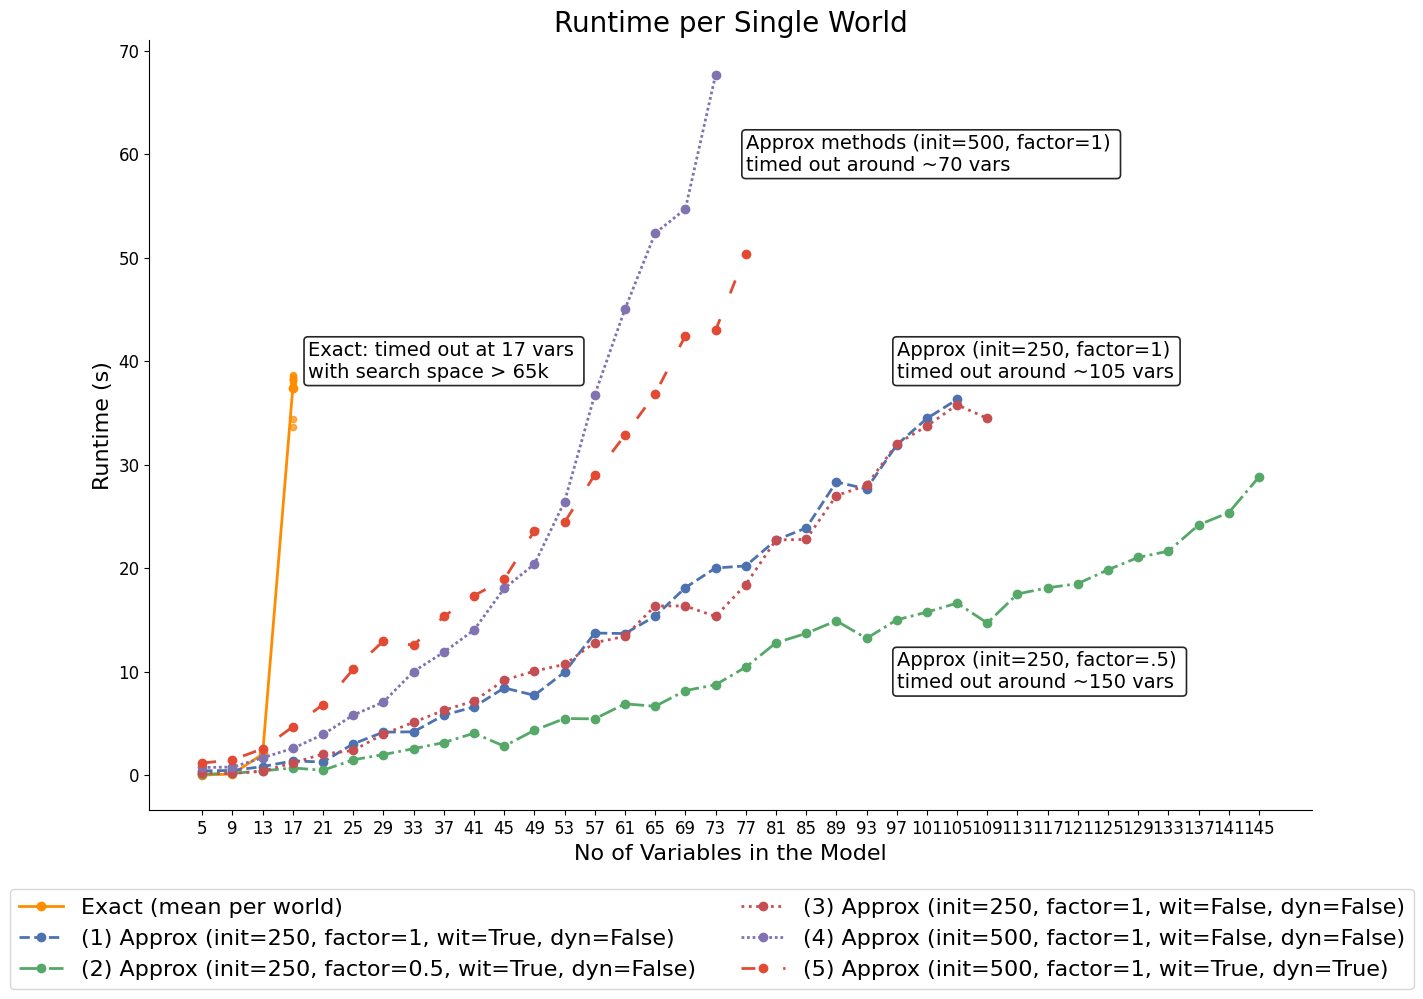

In [32]:
# ---------------------- PLOT 1 ----------------------
fig1, ax1 = plt.subplots(figsize=(15, 10))

ax1.set_title("Runtime Per Single World", fontsize=20)
ax1.set_xlabel("No of Variables in the Model", fontsize=16)
ax1.set_ylabel("Runtime (s)", fontsize=16)

# Scatter exact
for col in df_melted["Column"].unique():
    subset = df_melted[df_melted["Column"] == col]
    ax1.scatter(
        [col] * len(subset), subset["Runtime"], s=20, alpha=0.7, color="darkorange"
    )

# Mean summary line
ax1.plot(
    mean_vals["Column"],
    mean_vals["Runtime"],
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=6,
    color="darkorange",
    label="Exact (mean per world)",
)

max_sites = int(mean_vals["Column"].max())

# Approximate curves
for idx, (approx_result, color, lty) in enumerate(
    zip(approximate_results_list, colors, line_styles), start=1
):
    df = approx_result["runtime_per_observation_approx_df"]
    y_vals = df.T.squeeze().values
    x_vals = list(range(0, len(y_vals)))

    max_sites = max(max_sites, max(x_vals))

    size_parameters = list(range(1, max_sites + 2))
    numbers_of_variables = [str((4 * n) + 1) for n in size_parameters]

    ax1.plot(
        x_vals,
        y_vals,
        marker="o",
        linestyle=lty,
        linewidth=2,
        markersize=6,
        color=color,
        label=f"({idx}) Approx (init={approx_result['run_params']['initial_num_search_samples']}, "
        f"factor={approx_result['run_params']['linear_sample_size_factor']}, "
        f"wit={approx_result['run_params']['use_witnesses']}, "
        f"dyn={approx_result['run_params']['dynamic_set_sizes']})",
    )

# Annotate
add_line_end_label(
    ax1, 3.5, 40, "Exact: timed out at 17 vars \nwith search space > 65k"
)
add_line_end_label(
    ax1, 18, 60, "Approx methods (init=500, factor=1) \ntimed out around ~70 vars"
)
add_line_end_label(
    ax1, 23, 40, "Approx (init=250, factor=1) \ntimed out around ~105 vars"
)
add_line_end_label(
    ax1, 23, 10, "Approx (init=250, factor=.5) \ntimed out around ~150 vars"
)


ax1.tick_params(axis="both", labelsize=12)
ax1.set_xticks(range(0, max_sites + 1))
ax1.set_xticklabels(numbers_of_variables, fontsize=12)


fig1.legend(loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=16)
sns.despine()
# fig1.tight_layout()
fig1.savefig("ac_benchmark/plot1_runtime.png", bbox_inches="tight")
plt.show()

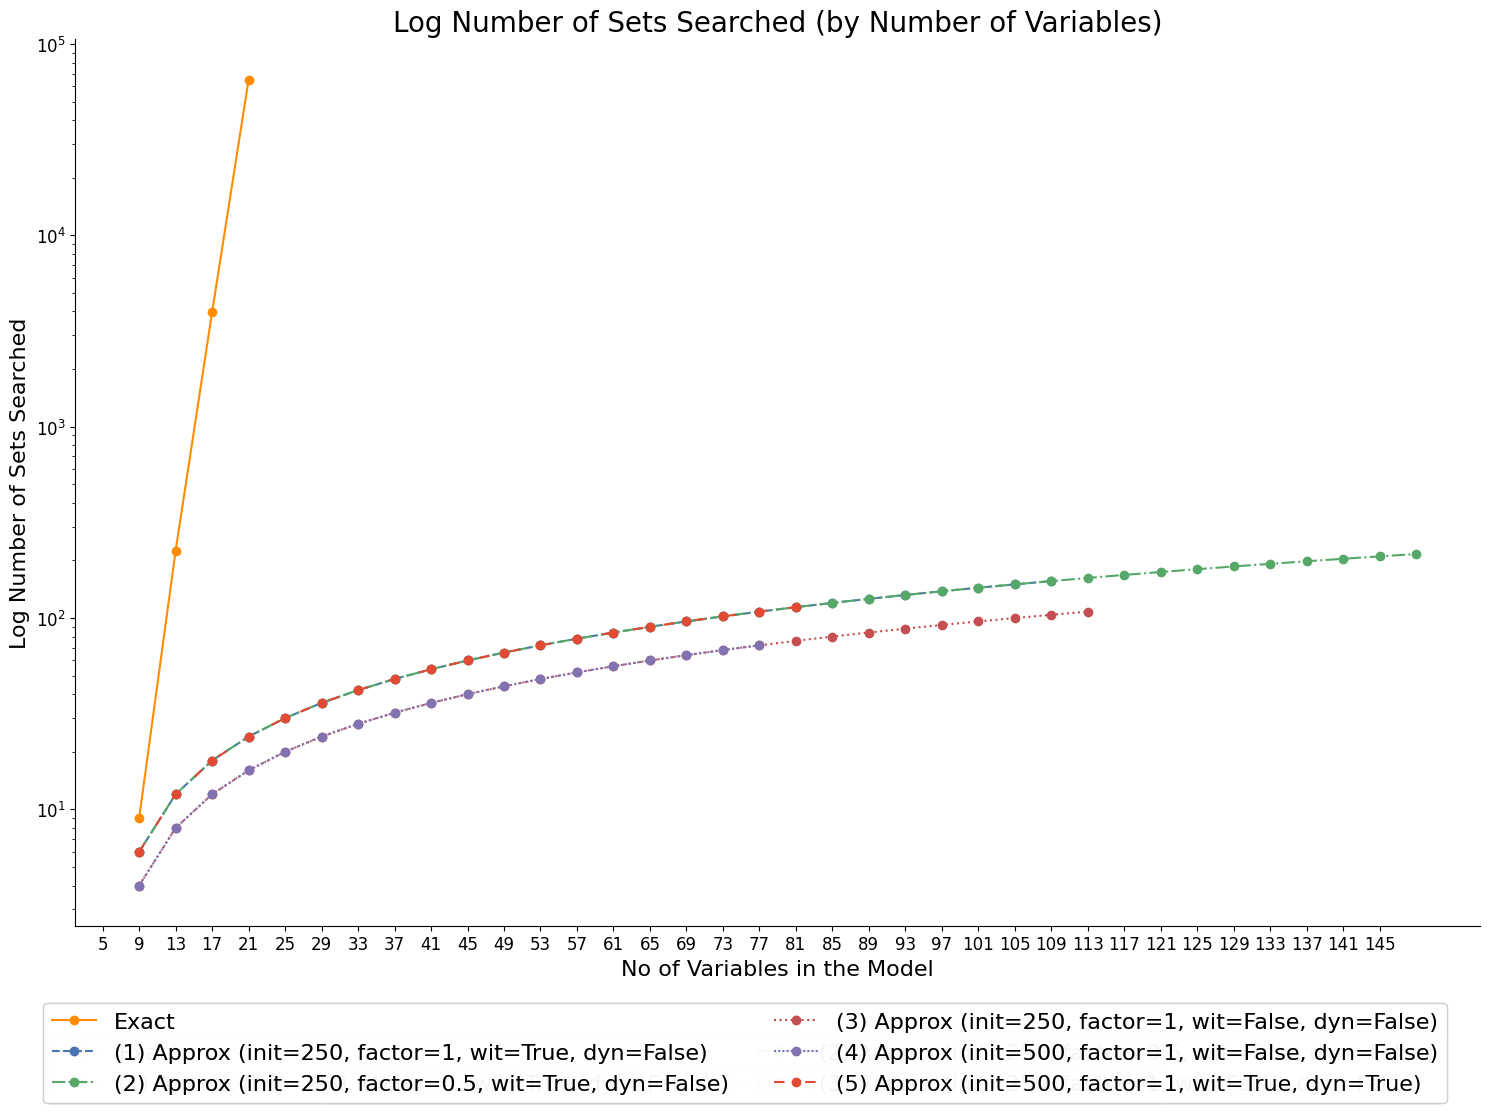

In [33]:
# ---------------------- PLOT 2 (updated, with exact data preserved) ----------------------
fig2, ax2 = plt.subplots(figsize=(15, 10))

ax2.set_title("Win Frequency Across Variable Set Sizes", fontsize=20)
ax2.set_xlabel("No of Variables in the Model", fontsize=16)
ax2.set_ylabel("Win Frequency", fontsize=16)

max_sites = 0


color = "darkorange"
ax2.plot(
    subsets_df.index, subsets_df["search_space"], marker="o", color=color, label="Exact"
)
ax2.set_title("Log Number Of Sets Searched (By Number Of Variables)", fontsize=20)
ax2.set_xlabel("No of Variables in the Model", fontsize=16)
ax2.set_ylabel("Log Number of Sets Searched", fontsize=16)

for idx, (approx_result, color, lty) in enumerate(
    zip(approximate_results_list, colors, line_styles), start=1
):
    df = approx_result["runtime_per_observation_approx_df"]
    y_vals = df.T.squeeze().values  # works for single-column/single-row frames
    x_vals = list(range(0, len(y_vals)))

    max_sites = max(max_sites, max(x_vals))

    size_parameters = list(range(1, max_sites + 2))
    numbers_of_variables = [str((4 * n) + 1) for n in size_parameters]

    for i in range(3):
        for tick in ax2.get_xticklabels():
            tick.set_fontsize(12)
        for tick in ax2.get_yticklabels():
            tick.set_fontsize(12)

        ax2.set_xticks(range(0, max_sites + 1))
        ax2.set_xticklabels(numbers_of_variables, fontsize=12)

    search_space_approx_df = approx_result["search_space_approx_df"]
    ax2.set_yscale("log")
    ax2.plot(
        search_space_approx_df.index,
        search_space_approx_df["search_space"],
        marker="o",
        linestyle=lty,
        color=color,
        label=f"({idx}) Approx (init={approx_result['run_params']['initial_num_search_samples']}, "
        f"factor={approx_result['run_params']['linear_sample_size_factor']}, "
        f"wit={approx_result['run_params']['use_witnesses']}, "
        f"dyn={approx_result['run_params']['dynamic_set_sizes']})",
    )

    fig2.legend(loc="lower center", ncol=2, fontsize=16, bbox_to_anchor=(0.5, -0.12))

sns.despine()
fig2.tight_layout()
fig2.savefig("ac_benchmark/plot2_search_space.png")
plt.show()

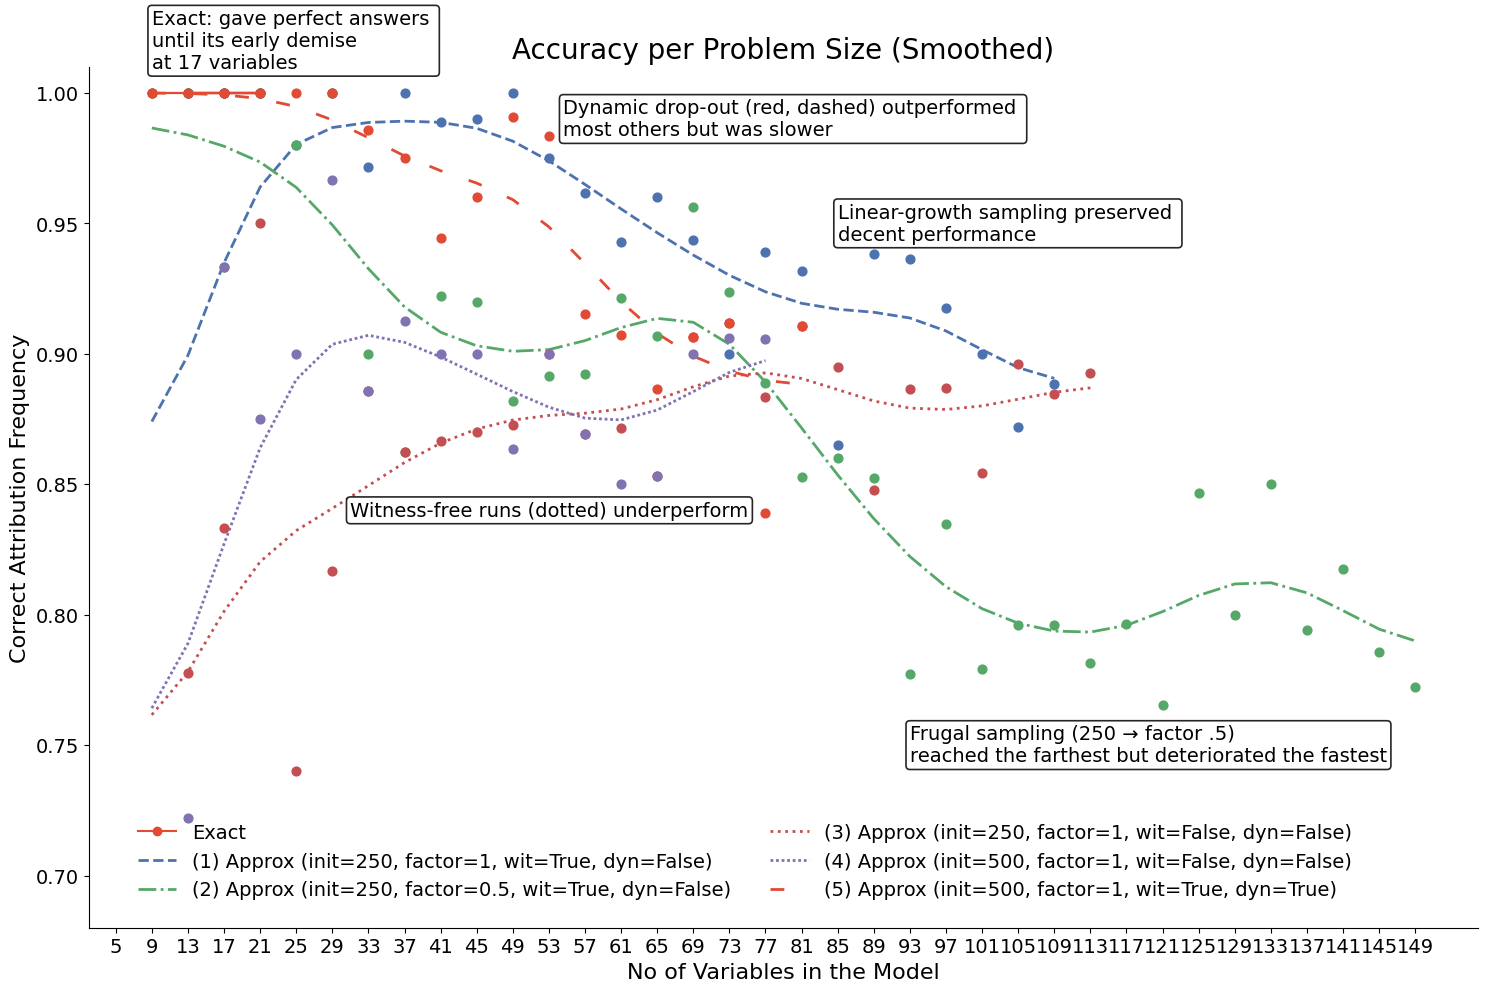

In [34]:
# ---------------------- PLOT 3 ----------------------
fig3, ax3 = plt.subplots(figsize=(15, 10))

ax3.set_title("Accuracy Per Problem Size (Smoothed)", fontsize=20)
ax3.set_xlabel("No of Variables in the Model", fontsize=16)
ax3.set_ylabel("Correct Attribution Frequency", fontsize=16)

max_sites = 0


label = "Exact"
for col in win_freqs_df.columns:
    ax3.plot(
        win_freqs_df.index, win_freqs_df[col], marker="o", color=color, label=label
    )
    label = None  # only label first line to avoid duplicates in legend

# Track maximum x
max_sites = max(max_sites, win_freqs_df.index.max())


# -------- APPROXIMATE LINES -------------------------------
for idx, (approx_result, color, lty) in enumerate(
    zip(approximate_results_list, colors, line_styles), start=1
):
    y = approx_result["win_freqs_approx_df"].squeeze().values
    y = np.array(y, dtype=float)

    # Gaussian smoothing
    y_smooth = gaussian_filter1d(y, sigma=2.0)

    x_vals = approx_result["win_freqs_approx_df"].index.values
    max_sites = max(max_sites, max(x_vals))

    # Smoothed line
    ax3.plot(
        x_vals,
        y_smooth,
        linestyle=lty,
        linewidth=2,
        color=color,
        label=(
            f"({idx}) Approx (init={approx_result['run_params']['initial_num_search_samples']}, "
            f"factor={approx_result['run_params']['linear_sample_size_factor']}, "
            f"wit={approx_result['run_params']['use_witnesses']}, "
            f"dyn={approx_result['run_params']['dynamic_set_sizes']})"
        ),
    )

    # Raw scatter
    ax3.scatter(x_vals, y, s=40, color=color, zorder=5)


# -------- X-TICKS (same as other figs) ---------------------
size_parameters = list(range(1, max_sites + 2))
numbers_of_variables = [str((4 * n) + 1) for n in size_parameters]

ax3.set_xticks(range(0, max_sites + 1))
ax3.set_xticklabels(numbers_of_variables, fontsize=14)
ax3.tick_params(axis="both", labelsize=14)

# -------- Y LIMITS ----------------------------------------
ax3.set_ylim(0.68, 1.01)

# -------- ANNOTATIONS -------------------------------------
add_line_end_label(
    ax3,
    1,
    1.02,
    "Exact: gave perfect answers \nuntil its early demise \nat 17 variables",
)

add_line_end_label(
    ax3,
    12.4,
    .99,
    "Dynamic drop-out (red, dashed) outperformed \nmost others but was slower",
)

add_line_end_label(
    ax3,
    22,
    0.75,
    "Frugal sampling (250 → factor .5)\nreached the farthest but deteriorated the fastest",
)

add_line_end_label(
    ax3, 20, .95, "Linear-growth sampling preserved \ndecent performance"
)

add_line_end_label(ax3, 6.5, 0.84, "Witness-free runs (dotted) underperform")


fig3.legend(
    loc="lower center", bbox_to_anchor=(0.5, 0.08), ncol=2, frameon=False, fontsize=14
)


sns.despine()
fig3.tight_layout()
fig3.savefig("ac_benchmark/plot3_accuracy.png")
plt.show()